# 02. Data Cleaning
## Structural Health Monitoring — Heritage Masonry Vaults

**Purpose:** Apply a three-phase cleaning pipeline to each sensor individually:
- **Phase 1:** Geometric filter — remove physically impossible values based on known installation distances
- **Phase 2:** Chauvenet Criterion — probabilistic outlier detection
- **Phase 3:** Iterative IQR filter — define the valid structural operating envelope

**Input:** `../data/processed/raw_unified.csv` — unified raw dataset from `01_data_ingestion.ipynb`

**Output:**
- `../data/processed/clean_{sensor}.csv` — one clean CSV per sensor
- `../outputs/tables/01_cleaning_summary.xlsx` — cleaning results summary table

**Next notebook:** `03_statistical_analysis.ipynb`

---
### Methodology Note
Each sensor is processed **independently** — the k-factor for the IQR filter and the geometric thresholds differ per sensor based on installation geometry and observed data quality. This is an intentional design choice: applying a single global filter would discard real structural events in some sensors while retaining noise in others.

The Chauvenet Criterion and IQR method are **complementary, not redundant**:
- Chauvenet removes values statistically unlikely to belong to the sample population
- IQR then defines the valid structural operating range on the Chauvenet-cleaned data

Quality thresholds (Ministerio de Ambiente Uruguay, Guía DCA 04 V.4.1):
- < 5% removed → Excellent
- 5–10% removed → Acceptable
- 10–15% removed → Review manually
- > 15% removed → Alert

---
## 0. Configuration

In [47]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd              # DataFrame handling and manipulation
import numpy as np               # Mathematical functions
import scipy as sp               # Statistical models
import matplotlib.pyplot as plt  # Graphs
import seaborn as sns            # Graphs
import os                        # Directory and path management
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from sklearn.preprocessing import MinMaxScaler
from datetime import datetime

# ============================================================
# SENSOR CONFIGURATION DICTIONARY
# Maps each sensor to its zone, axis, and plot color
# Odd sensors = diagonal axis | Even sensors = horizontal axis
# ============================================================
SENSOR_CONFIG = {
    'S01': {'zone': 'Zone A', 'axis': '(Diag.)', 'color': '#0563C1'},
    'S02': {'zone': 'Zone A', 'axis': '(Hor.)',  'color': '#ADD8E6'},
    'S03': {'zone': 'Zone A', 'axis': '(Diag.)', 'color': '#0563C1'},
    'S04': {'zone': 'Zone A', 'axis': '(Hor.)',  'color': '#ADD8E6'},
    'S05': {'zone': 'Zone B', 'axis': '(Diag.)', 'color': '#FFA500'},
    'S06': {'zone': 'Zone B', 'axis': '(Hor.)',  'color': '#FFD580'},
    'S07': {'zone': 'Zone B', 'axis': '(Diag.)', 'color': '#FFA500'},
    'S08': {'zone': 'Zone B', 'axis': '(Hor.)',  'color': '#FFD580'},
    'S09': {'zone': 'Zone C', 'axis': '(Diag.)', 'color': '#6EAB54'},
    'S10': {'zone': 'Zone C', 'axis': '(Hor.)',  'color': '#B6D5A9'},
    'S11': {'zone': 'Zone C', 'axis': '(Diag.)', 'color': '#6EAB54'},
    'S12': {'zone': 'Zone C', 'axis': '(Hor.)',  'color': '#B6D5A9'},
}

SENSORS = list(SENSOR_CONFIG.keys())

# ============================================================
# K_FACTORS — auto-populated by find_optimal_k() in Section 5
# Pre-loaded with values validated during original analysis.
# Re-running Section 5 (full pipeline) will recompute and
# overwrite these values automatically.
# ============================================================
K_FACTORS = {
    'S01': 5, 'S02': 5, 'S03': 1, 'S04': 3,
    'S05': 2, 'S06': 3, 'S07': 3, 'S08': 2,
    'S09': 2, 'S10': 4, 'S11': 2, 'S12': 3
}

# ============================================================
# PATHS — relative, works from any machine
# ============================================================
RAW_DATA_PATH       = '../data/processed/raw_unified.csv'
PROCESSED_DATA_PATH = '../data/processed/'
TABLES_PATH         = '../outputs/tables/'

os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)
os.makedirs(TABLES_PATH, exist_ok=True)

# ============================================================
# ACTIVE SENSOR — used for single-sensor exploratory sections
# Change this to inspect any individual sensor in detail.
# Full automated pipeline in Section 5 runs ALL sensors.
# ============================================================
sensor = 'S01'   # <-- CHANGE for single-sensor inspection (Sections 1-4)

config = SENSOR_CONFIG[sensor]
factor = K_FACTORS[sensor]

# ============================================================
# PHYSICAL VALIDITY FILTERS — sensor-specific, Phase 1
#
# S09: two-stage filter for bimodal connectivity failure.
#   Stage 1 — minimum distance: 7520mm
#     Zero-density valley between disconnected cluster
#     (~2807mm mean) and structural signal (~12618mm mean).
#   Stage 2 — rate-of-change: 13mm per 15-min interval
#     = 3× P99 of consecutive diffs in S11 (same zone,
#     same axis, clean reference sensor, P99 = 4.33mm).
# ============================================================
GEOMETRIC_THRESHOLDS = {s: None for s in SENSORS}
GEOMETRIC_THRESHOLDS['S09'] = 7520.0

MAX_RATE_OF_CHANGE = {s: None for s in SENSORS}
MAX_RATE_OF_CHANGE['S09'] = 13.0

print(f'Active sensor: {sensor} | Zone: {config["zone"]} | Axis: {config["axis"]} | k-factor: {factor}')
print(f'\nTo run full automated pipeline for all sensors: go to Section 5.')
print(GEOMETRIC_THRESHOLDS)


Active sensor: S01 | Zone: Zone A | Axis: (Diag.) | k-factor: 5

To run full automated pipeline for all sensors: go to Section 5.
{'S01': None, 'S02': None, 'S03': None, 'S04': None, 'S05': None, 'S06': None, 'S07': None, 'S08': None, 'S09': 7520.0, 'S10': None, 'S11': None, 'S12': None}


---
## 1. Load Data

In [48]:
# ============================================================
# LOAD RAW DATASET
# ============================================================
df_Original = pd.read_csv(RAW_DATA_PATH)
df00 = df_Original[['Timestamp', sensor, 'Hum.', 'Pres.', 'Temp.']].copy()

# Timestamp format correction
df00['Timestamp'] = pd.to_datetime(df00['Timestamp'], format='%Y-%m-%d %H:%M:%S')

# Exclude March 2025 — irregular readings during installation and calibration period
df0 = df00[df00['Timestamp'].dt.month.isin([1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12])].copy()

df0.info()
print(f'\nNull values per column:')
print(df0.isna().sum())
df0.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 3463 entries, 0 to 3462
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Timestamp  3463 non-null   datetime64[us]
 1   S01        3363 non-null   float64       
 2   Hum.       3425 non-null   float64       
 3   Pres.      3425 non-null   float64       
 4   Temp.      3425 non-null   float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 135.4 KB

Null values per column:
Timestamp      0
S01          100
Hum.          38
Pres.         38
Temp.         38
dtype: int64


,Timestamp,S01,Hum.,Pres.,Temp.
0,2025-04-01 13:00:00,12633.00,45.17,1013.69,28.37
1,2025-04-01 15:00:00,12632.06,37.04,1011.57,33.41
2,2025-04-01 17:00:00,12633.50,37.26,1010.26,31.13
3,2025-04-01 19:00:00,12632.71,41.91,1009.54,28.28
4,2025-04-01 21:00:00,12632.45,45.88,1009.84,26.78


---
## 2. Initial Data Quality Check

In [49]:
# ============================================================
# 2.1. DATA QUALITY CHECK
# ============================================================
df = df0.copy()  # Working copy

total_timestamps = df['Timestamp'].count()
sensor_values    = df[sensor].count()
pct_valid        = sensor_values * 100 / total_timestamps

print(f"""
Total timestamp records: {total_timestamps}
Valid records for {sensor}: {sensor_values} ({pct_valid:.2f}%)
Null records: {total_timestamps - sensor_values} ({100 - pct_valid:.2f}%)
""")

# ============================================================
# 2.2. REMOVE NULL VALUES FOR ACTIVE SENSOR
# ============================================================
df = df0.dropna(subset=[sensor])
df.info()


Total timestamp records: 3463
Valid records for S01: 3363 (97.11%)
Null records: 100 (2.89%)

<class 'pandas.DataFrame'>
Index: 3363 entries, 0 to 3462
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Timestamp  3363 non-null   datetime64[us]
 1   S01        3363 non-null   float64       
 2   Hum.       3347 non-null   float64       
 3   Pres.      3347 non-null   float64       
 4   Temp.      3347 non-null   float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 157.6 KB


---
## 3. Raw Data Visualization

Initial visual inspection of raw data before cleaning.
Includes statistical summary, temporal evolution, and correlation with environmental variables.

In [50]:
# ============================================================
# 3.1. SENSOR STATISTICS — RAW DATA
# ============================================================
correlation_data = df[[sensor, 'Temp.', 'Hum.', 'Pres.']].corr()

p5  = df[sensor].quantile(0.05)
p25 = df[sensor].quantile(0.25)
p50 = df[sensor].quantile(0.50)
p75 = df[sensor].quantile(0.75)
p95 = df[sensor].quantile(0.95)
IQR = p75 - p25

limite_inferior = p25 - 1.5 * IQR
limite_superior = p75 + 1.5 * IQR

print(f"""
=== STATISTICS {sensor} {config['axis']} — {config['zone']} ===
Total records: {len(df)}

DISTRIBUTION:
  Min:           {df[sensor].min():.2f}
  P25:           {p25:.2f}
  Median (P50):  {p50:.2f}
  P75:           {p75:.2f}
  Max:           {df[sensor].max():.2f}

STATISTICS:
  Mean:          {df[sensor].mean():.2f}
  Std. Dev.:     {df[sensor].std():.2f}
  Range:         {df[sensor].max() - df[sensor].min():.2f}
  IQR:           {IQR:.2f}

OUTLIERS (IQR method, k=1.5):
  Lower limit:   {limite_inferior:.2f}
  Upper limit:   {limite_superior:.2f}
  Detected:      {len(df[(df[sensor] < limite_inferior) | (df[sensor] > limite_superior)])}
  Percentage:    {len(df[(df[sensor] < limite_inferior) | (df[sensor] > limite_superior)])/len(df)*100:.2f}%

CORRELATION WITH ENVIRONMENTAL VARIABLES:
  Temperature:   {correlation_data.loc[sensor, 'Temp.']:.2f}
  Humidity:      {correlation_data.loc[sensor, 'Hum.']:.2f}
  Pressure:      {correlation_data.loc[sensor, 'Pres.']:.2f}
""")


=== STATISTICS S01 (Diag.) — Zone A ===
Total records: 3363

DISTRIBUTION:
  Min:           12630.38
  P25:           12632.00
  Median (P50):  12632.56
  P75:           12633.11
  Max:           12638.18

STATISTICS:
  Mean:          12632.74
  Std. Dev.:     1.07
  Range:         7.80
  IQR:           1.11

OUTLIERS (IQR method, k=1.5):
  Lower limit:   12630.33
  Upper limit:   12634.78
  Detected:      177
  Percentage:    5.26%

CORRELATION WITH ENVIRONMENTAL VARIABLES:
  Temperature:   0.61
  Humidity:      -0.41
  Pressure:      -0.49



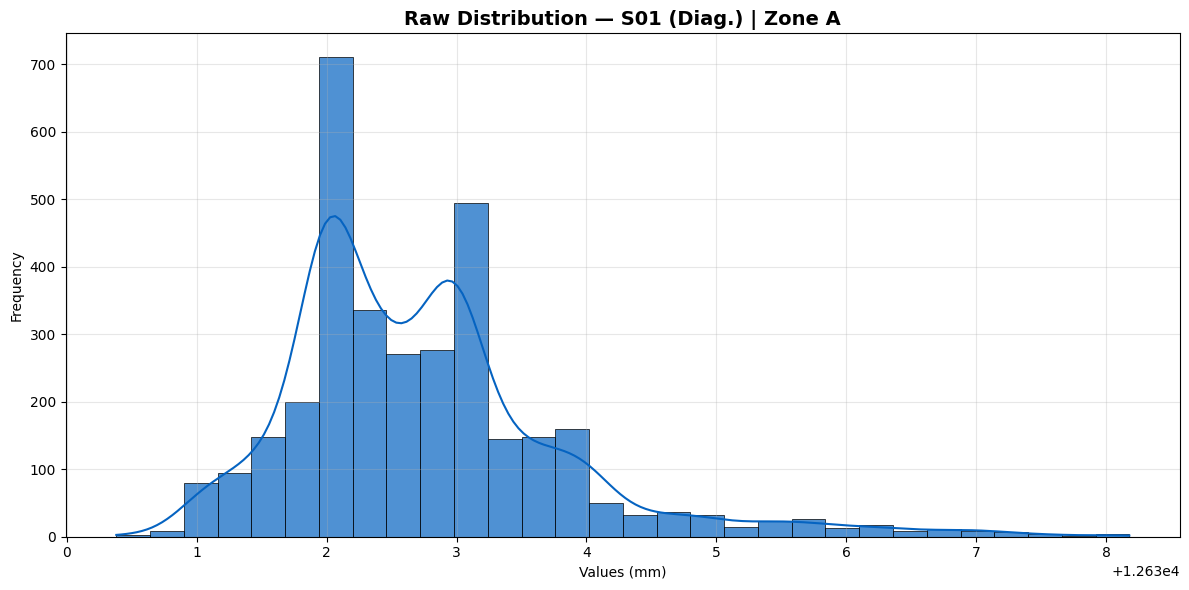

In [51]:
# ============================================================
# 3.2. RAW DISTRIBUTION — histogram
# ============================================================
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x=sensor, bins=30, kde=True,
             color=config['color'], alpha=0.7, edgecolor='black', linewidth=0.5)
plt.title(f'Raw Distribution — {sensor} {config["axis"]} | {config["zone"]}',
          fontsize=14, fontweight='bold')
plt.xlabel('Values (mm)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

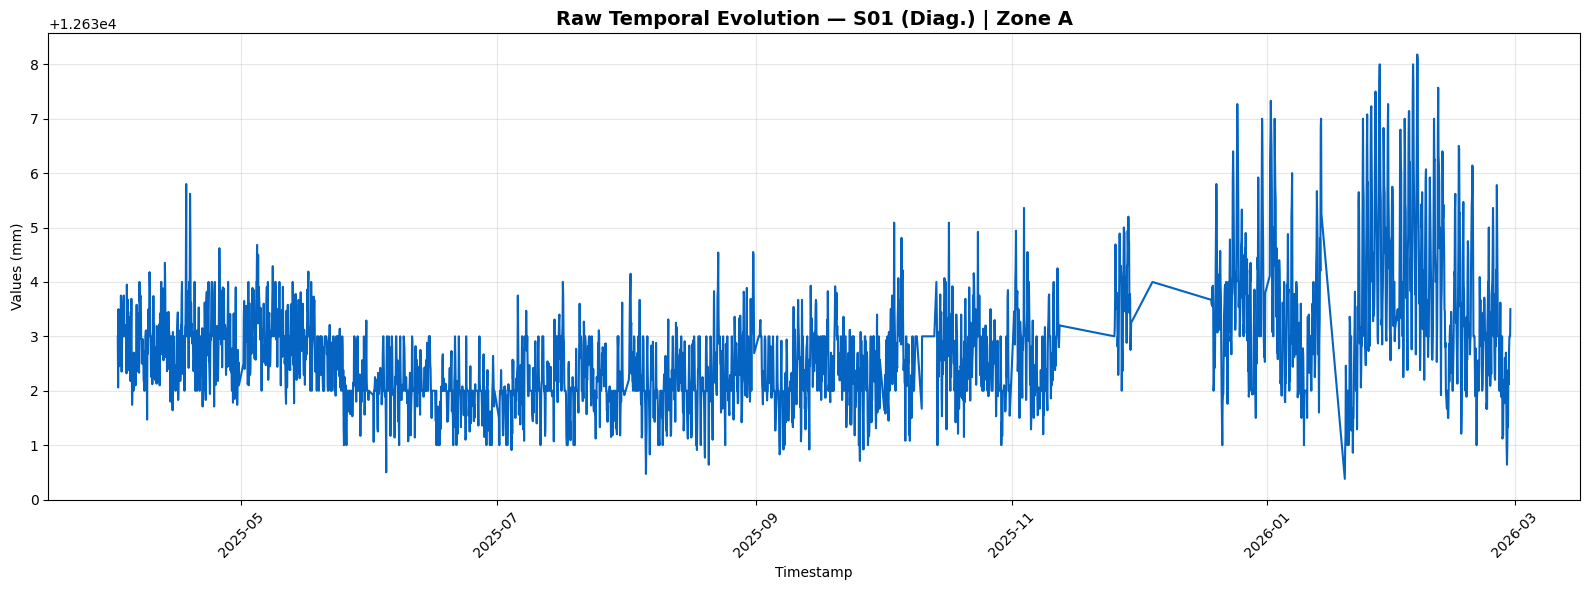

In [52]:
# ============================================================
# 3.3. RAW TEMPORAL EVOLUTION
# ============================================================
plt.figure(figsize=(16, 6))
sns.lineplot(data=df, x='Timestamp', y=sensor, linewidth=1.5, color=config['color'])
plt.title(f'Raw Temporal Evolution — {sensor} {config["axis"]} | {config["zone"]}',
          fontsize=14, fontweight='bold')
plt.xlabel('Timestamp')
plt.ylabel('Values (mm)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [53]:
# ============================================================
# 3.4. NORMALIZE ENVIRONMENTAL VARIABLES FOR COMPARISON
# MinMaxScaler maps all variables to 0–10 range for overlay
# ============================================================
df_normalized = df.copy()

scaler_sensor = MinMaxScaler(feature_range=(0, 10))
df_normalized[sensor] = scaler_sensor.fit_transform(df[[sensor]])

for var in ['Temp.', 'Hum.', 'Pres.']:
    scaler_var = MinMaxScaler(feature_range=(0, 10))
    df_normalized[var] = scaler_var.fit_transform(df[[var]].fillna(df[var].mean()))

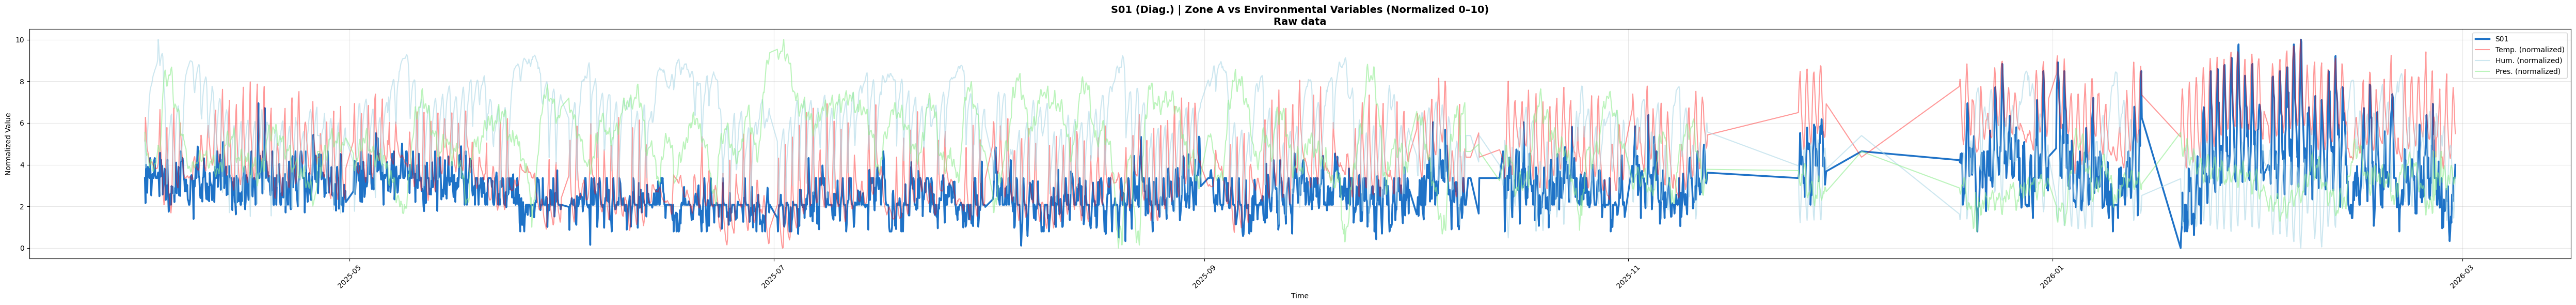

In [54]:
# ============================================================
# 3.5. SENSOR vs ENVIRONMENTAL VARIABLES — normalized overlay
# ============================================================
plt.figure(figsize=(50, 6))

plt.plot(df_normalized['Timestamp'], df_normalized[sensor],
         label=sensor, linewidth=2.5, color=config['color'], alpha=0.9)
plt.plot(df_normalized['Timestamp'], df_normalized['Temp.'],
         label='Temp. (normalized)', linewidth=1.5, alpha=0.4, color='red')
plt.plot(df_normalized['Timestamp'], df_normalized['Hum.'],
         label='Hum. (normalized)', linewidth=1.5, alpha=0.6, color='lightblue')
plt.plot(df_normalized['Timestamp'], df_normalized['Pres.'],
         label='Pres. (normalized)', linewidth=1.5, alpha=0.6, color='lightgreen')

plt.title(f'{sensor} {config["axis"]} | {config["zone"]} vs Environmental Variables (Normalized 0–10)\nRaw data',
          fontsize=14, fontweight='bold')
plt.xlabel('Time')
plt.ylabel('Normalized Value')
plt.legend(loc='upper right', fontsize=10)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

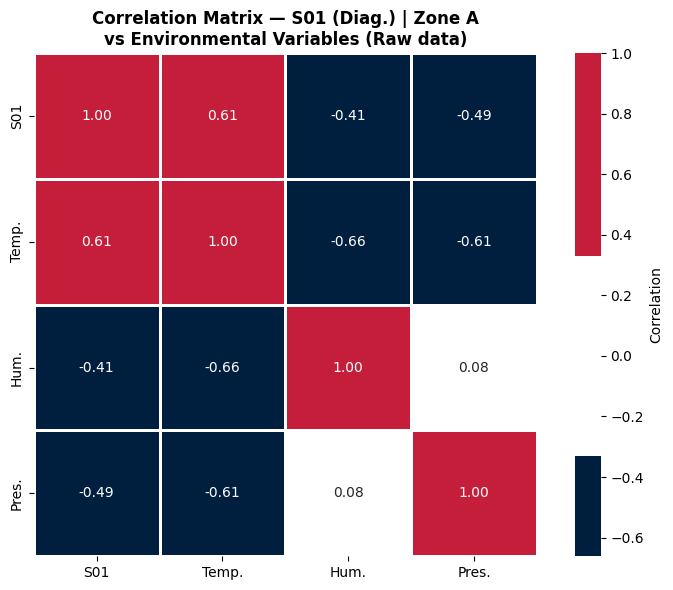

In [55]:
# ============================================================
# 3.6. CORRELATION MATRIX — raw data
# ============================================================
colores_custom = [
    '#001F3F',  # Navy blue (negative correlation)
    '#FFFFFF',  # White (no correlation)
    '#C41E3A',  # Crimson red (positive correlation)
]

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_data, annot=True, fmt='.2f', cmap=colores_custom,
            center=0, square=True, linewidths=2, cbar_kws={'label': 'Correlation'})
plt.title(f'Correlation Matrix — {sensor} {config["axis"]} | {config["zone"]}\nvs Environmental Variables (Raw data)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Outlier Method Comparison

Visual comparison of four outlier detection methods on raw data.
This section supports the k-factor selection decision in Section 5.
The IQR extended method (k×IQR) is the one ultimately applied.


OUTLIER METHOD COMPARISON — S01 (Diag.) | Zone A
Original: 3363 records

Method       | Range                  | Valid        | Removed      | % Valid   
----------------------------------------------------------------------------------------------------

±1σ          | 12631.66–12633.81      | 2623         | 740          | 78.0      %
±2σ          | 12630.59–12634.89      | 3196         | 167          | 95.0      %
IQR          | 12632.00–12633.11      | 1988         | 1375         | 59.1      %
IQR k×       | 12630.33–12634.78      | 3186         | 177          | 94.7      %


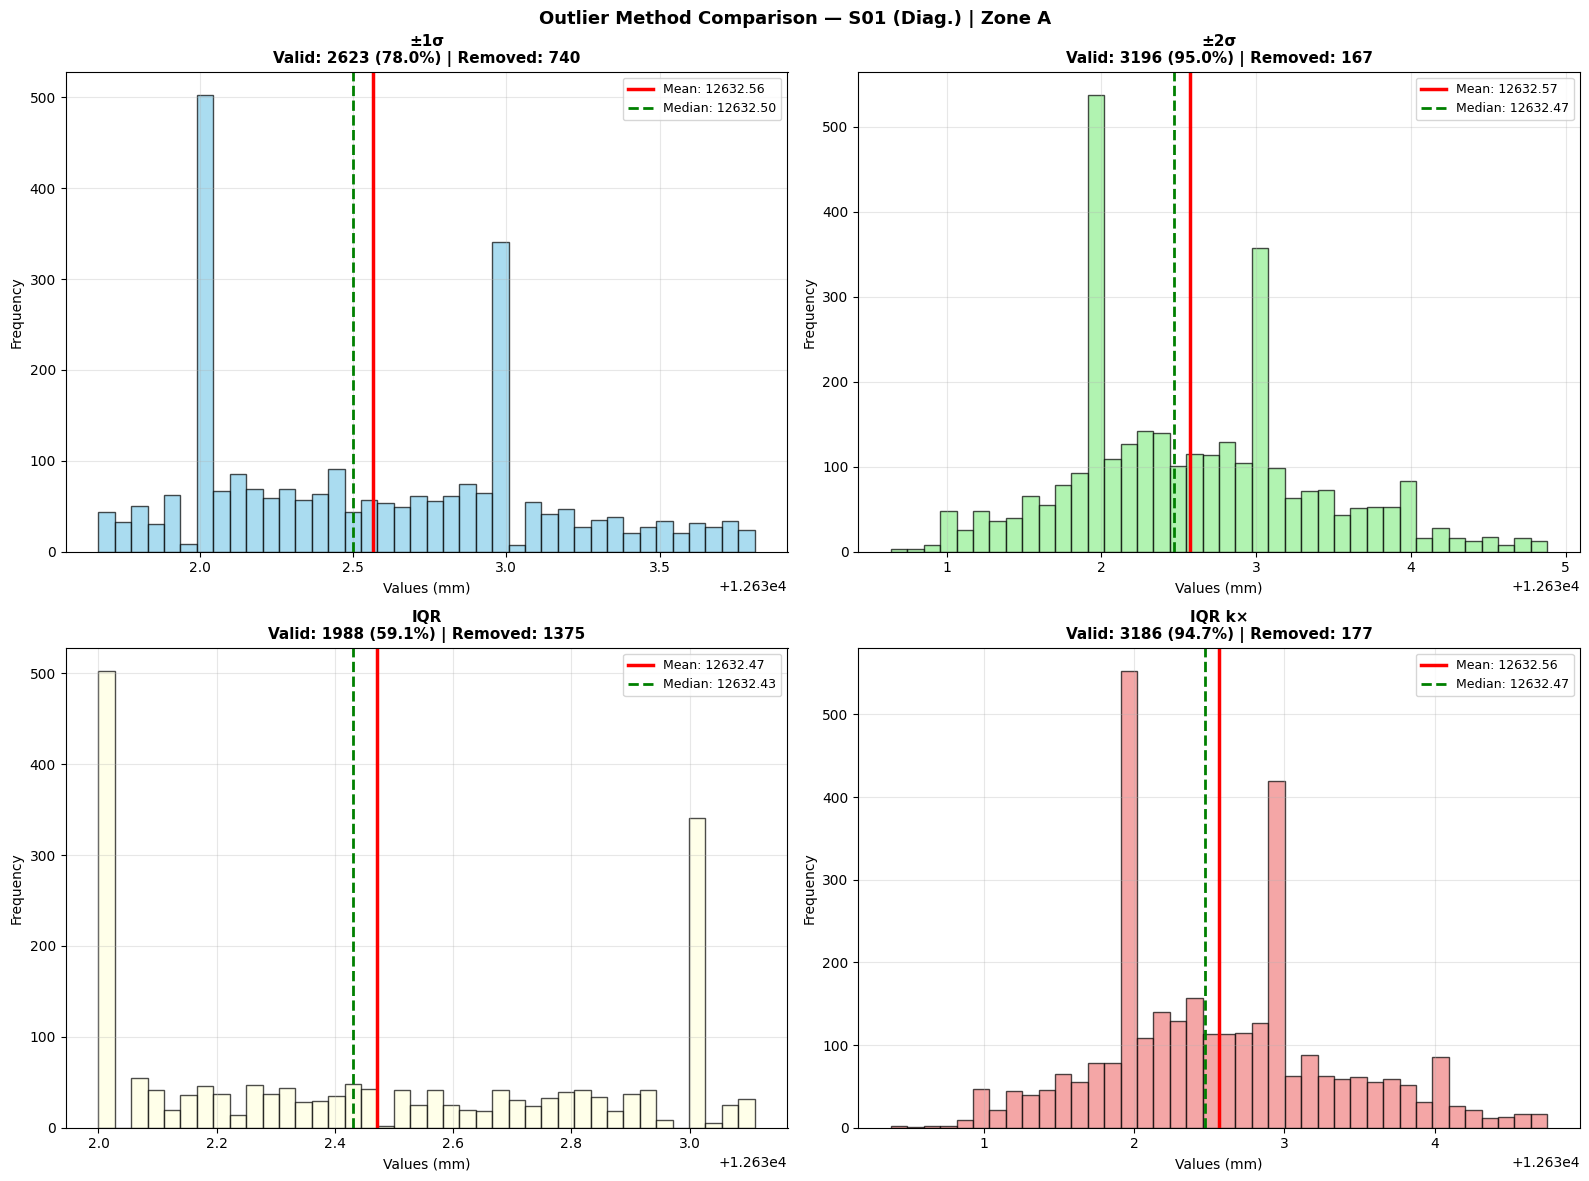

In [56]:
# ============================================================
# 4. OUTLIER METHOD COMPARISON
# Compares four methods: ±1σ, ±2σ, IQR, IQR extended (k×)
# ============================================================
datos = df[sensor]

media = datos.mean()
std   = datos.std()
p25   = datos.quantile(0.25)
p50   = datos.quantile(0.50)
p75   = datos.quantile(0.75)
IQR   = p75 - p25

metodos = {
    '±1σ':    (media - std,       media + std),
    '±2σ':    (media - 2*std,     media + 2*std),
    'IQR':    (p25,               p75),
    'IQR k×': (p25 - 1.5 * IQR,  p75 + 1.5 * IQR),
}

df_filtrados   = {}
estadisticas   = {}

for nombre, (inf, sup) in metodos.items():
    df_filt = df[(df[sensor] >= inf) & (df[sensor] <= sup)].copy()
    df_filtrados[nombre] = df_filt
    datos_filt = df_filt[sensor].dropna()
    estadisticas[nombre] = {
        'nombre'          : nombre,
        'limite_inf'      : inf,
        'limite_sup'      : sup,
        'datos_validos'   : len(df_filt),
        'datos_eliminados': len(df) - len(df_filt),
        'porcentaje'      : (len(df_filt) / len(df)) * 100,
        'media'           : datos_filt.mean(),
        'std'             : datos_filt.std(),
        'min'             : datos_filt.min(),
        'max'             : datos_filt.max(),
    }

# Comparative table
print(f"""
{'='*100}
OUTLIER METHOD COMPARISON — {sensor} {config['axis']} | {config['zone']}
{'='*100}
Original: {len(df)} records

{'Method':<12} | {'Range':<22} | {'Valid':<12} | {'Removed':<12} | {'% Valid':<10}
{'-'*100}
""")

for nombre, stats in estadisticas.items():
    rango = f"{stats['limite_inf']:.2f}–{stats['limite_sup']:.2f}"
    print(f"{nombre:<12} | {rango:<22} | {stats['datos_validos']:<12} | {stats['datos_eliminados']:<12} | {stats['porcentaje']:<10.1f}%")

# Comparative histograms
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
colores_hist = ['skyblue', 'lightgreen', 'lightyellow', 'lightcoral']

for idx, (nombre, df_filt) in enumerate(df_filtrados.items()):
    datos_filt = df_filt[sensor].dropna()
    axes[idx].hist(datos_filt, bins=40, edgecolor='black', alpha=0.7, color=colores_hist[idx])
    axes[idx].axvline(datos_filt.mean(),   color='red',   linestyle='-',  linewidth=2.5, label=f'Mean: {datos_filt.mean():.2f}')
    axes[idx].axvline(datos_filt.median(), color='green', linestyle='--', linewidth=2,   label=f'Median: {datos_filt.median():.2f}')
    titulo = f"{nombre}\nValid: {len(df_filt)} ({len(df_filt)/len(df)*100:.1f}%) | Removed: {len(df)-len(df_filt)}"
    axes[idx].set_title(titulo, fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Values (mm)')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle(f'Outlier Method Comparison — {sensor} {config["axis"]} | {config["zone"]}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4.1. Raw Data Percentile Distribution

Detailed percentile breakdown of raw data.
Used to understand the distribution shape before cleaning and to validate the geometric filter threshold.

In [57]:
# ============================================================
# 4.1. RAW DATA PERCENTILE DISTRIBUTION TABLE
# ============================================================
datos = df[sensor].copy()

p1    = float(datos.quantile(0.01))
p2_5  = float(datos.quantile(0.025))
p5    = float(datos.quantile(0.05))
p10   = float(datos.quantile(0.10))
Q1    = float(datos.quantile(0.25))
p50   = float(datos.quantile(0.50))
Q3    = float(datos.quantile(0.75))
p90   = float(datos.quantile(0.90))
p95   = float(datos.quantile(0.95))
p97_5 = float(datos.quantile(0.975))
p99   = float(datos.quantile(0.99))

rangos_data = []
rango_1 = len(datos[datos <= p1])
rangos_data.append({'Range': 'Min → P1', 'Lower (mm)': f'{datos.min():.2f}', 'Upper (mm)': f'{p1:.2f}',
                    'Difference': f'{p1 - datos.min():.2f}', 'Count': rango_1,
                    '%': f'{(rango_1/len(datos)*100):.2f}%', 'Cumulative': f'{(rango_1/len(datos)*100):.2f}%'})

rangos_intermedios = [
    ('P1', p1, 'P2.5', p2_5), ('P2.5', p2_5, 'P5', p5), ('P5', p5, 'P10', p10),
    ('P10', p10, 'Q1', Q1), ('Q1', Q1, 'P50', p50), ('P50', p50, 'Q3', Q3),
    ('Q3', Q3, 'P90', p90), ('P90', p90, 'P95', p95), ('P95', p95, 'P97.5', p97_5),
    ('P97.5', p97_5, 'P99', p99),
]

acumulado_anterior = rango_1
for nombre_inf, val_inf, nombre_sup, val_sup in rangos_intermedios:
    n = len(datos[(datos > val_inf) & (datos <= val_sup)])
    acumulado = acumulado_anterior + n
    rangos_data.append({'Range': f'{nombre_inf} → {nombre_sup}', 'Lower (mm)': f'{val_inf:.2f}',
                        'Upper (mm)': f'{val_sup:.2f}', 'Difference': f'{val_sup - val_inf:.2f}',
                        'Count': n, '%': f'{(n/len(datos)*100):.2f}%',
                        'Cumulative': f'{(acumulado/len(datos)*100):.2f}%'})
    acumulado_anterior = acumulado

rango_final = len(datos[datos > p99])
rangos_data.append({'Range': 'P99 → Max', 'Lower (mm)': f'{p99:.2f}', 'Upper (mm)': f'{datos.max():.2f}',
                    'Difference': f'{datos.max() - p99:.2f}', 'Count': rango_final,
                    '%': f'{(rango_final/len(datos)*100):.2f}%', 'Cumulative': '100.00%'})

df_rangos_raw = pd.DataFrame(rangos_data)

print(f"\n{'='*120}")
print(f"PERCENTILE DISTRIBUTION — {sensor} {config['axis']} | {config['zone']} — RAW DATA")
print(f"{'='*120}\n")
print(df_rangos_raw.to_string(index=False))
print(f"\n{'='*120}")
print(f"""
GENERAL STATISTICS:
  Total records: {len(datos)}
  Min: {datos.min():.2f}   Max: {datos.max():.2f}   Range: {datos.max() - datos.min():.2f}
  Mean: {datos.mean():.2f}   Median: {p50:.2f}   Std. Dev.: {datos.std():.2f}

KEY RANGES:
  IQR (Q1–Q3): {Q1:.2f} to {Q3:.2f}  (50% central) — Amplitude: {Q3-Q1:.2f}
  P5–P95:      {p5:.2f} to {p95:.2f}  (90% central) — Amplitude: {p95-p5:.2f}
  P2.5–P97.5:  {p2_5:.2f} to {p97_5:.2f}  (95% central) — Amplitude: {p97_5-p2_5:.2f}
  P1–P99:      {p1:.2f} to {p99:.2f}  (98% central) — Amplitude: {p99-p1:.2f}
""")


PERCENTILE DISTRIBUTION — S01 (Diag.) | Zone A — RAW DATA

      Range Lower (mm) Upper (mm) Difference  Count      % Cumulative
   Min → P1   12630.38   12631.00       0.62     63  1.87%      1.87%
  P1 → P2.5   12631.00   12631.14       0.14     22  0.65%      2.53%
  P2.5 → P5   12631.14   12631.38       0.24     89  2.65%      5.17%
   P5 → P10   12631.38   12631.70       0.32    170  5.06%     10.23%
   P10 → Q1   12631.70   12632.00       0.30    699 20.79%     31.01%
   Q1 → P50   12632.00   12632.56       0.56    648 19.27%     50.28%
   P50 → Q3   12632.56   12633.11       0.55    837 24.89%     75.17%
   Q3 → P90   12633.11   12634.00       0.89    544 16.18%     91.35%
  P90 → P95   12634.00   12634.82       0.82    122  3.63%     94.97%
P95 → P97.5   12634.82   12635.75       0.93     85  2.53%     97.50%
P97.5 → P99   12635.75   12636.65       0.90     50  1.49%     98.99%
  P99 → Max   12636.65   12638.18       1.53     34  1.01%    100.00%


GENERAL STATISTICS:
  Total 

---
## 5. Automated k-Factor Selection + Full Cleaning Pipeline

This section runs the complete cleaning pipeline **for all 12 sensors automatically**.

### How the k-factor is selected:

The `find_optimal_k()` function iterates k from 1 upward and computes the percentage change
in valid records between consecutive k values. It stops when that change falls below
**0.2%** — the threshold derived from the actual stabilization behavior observed across
all sensors in this project.

This threshold was determined empirically: at the chosen k, the change to k+1 was
consistently 0.00%–0.20% across all sensors, while the change from k-1 to k was
typically 0.06%–6.0% (still meaningful). The 0.2% threshold reliably identifies the
first point of true stabilization.

### What this section does:
1. For each sensor: finds optimal k automatically
2. Applies geometric filter (null removal)
3. Applies Chauvenet Criterion
4. Applies IQR filter with auto-selected k
5. Exports clean CSV per sensor
6. Exports cleaning summary table

> The K_FACTORS dictionary in Section 0 is updated with the computed values.
> Sections 1–4 remain available for single-sensor exploratory analysis.


In [58]:
# ============================================================
# AUTOMATED k-FACTOR SELECTION FUNCTION
# Iterates k from 1 upward. Stops when the percentage change
# in valid records between k and k+1 falls below threshold.
# Threshold = 0.2% — derived from stabilization behavior
# observed across all sensors in this project.
# ============================================================
def find_optimal_k(data, sensor_name, k_max=15, threshold=0.002, verbose=True):
    """
    Automatically selects the optimal IQR k-factor.
    
    Iterates k = 1, 2, 3... and computes the % change in valid
    records between consecutive k values. Stops at the first k
    where the change to k+1 drops below threshold (stabilization).
    
    Parameters:
        data       : pd.Series — sensor values (nulls already removed)
        sensor_name: str — for display only
        k_max      : int — maximum k to try before giving up
        threshold  : float — stabilization threshold (default 0.002 = 0.2%)
        verbose    : bool — print iteration table
    
    Returns:
        optimal_k  : int — selected k-factor
    """
    Q1  = data.quantile(0.25)
    Q3  = data.quantile(0.75)
    IQR = Q3 - Q1
    n   = len(data)

    if verbose:
        print(f"  k-factor iteration — {sensor_name}")
        print(f"  Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}  n={n}")
        print(f"  {'k':<5} | {'Valid':<8} | {'% Valid':<10} | {'Change to k+1':<16} | {'Decision'}")
        print(f"  {'-'*65}")

    prev_pct = None
    optimal_k = k_max  # fallback

    for k in range(1, k_max + 1):
        lim_inf = Q1 - k * IQR
        lim_sup = Q3 + k * IQR
        valid   = len(data[(data >= lim_inf) & (data <= lim_sup)])
        pct     = valid / n * 100

        if prev_pct is not None:
            change = abs(pct - prev_pct) / prev_pct if prev_pct > 0 else 0

            if change < threshold:
                # Stabilization reached at k-1 — previous k was the right one
                optimal_k = k - 1
                if verbose:
                    print(f"  {k:<5} | {valid:<8} | {pct:<10.4f} | {change*100:<16.4f} | ← STABILIZED at k={optimal_k}")
                    print(f"  {'-'*65}")
                    print(f"  ✓ Optimal k = {optimal_k}  (change {change*100:.2f}% < threshold {threshold*100}%)")
                break
            else:
                if verbose:
                    decision = 'continuing...' if change >= threshold else ''
                    print(f"  {k:<5} | {valid:<8} | {pct:<10.4f} | {change*100:<16.4f} | {decision}")
        else:
            if verbose:
                print(f"  {k:<5} | {valid:<8} | {pct:<10.4f} | {'(first)':<16} |")

        prev_pct = pct

    else:
        if verbose:
            print(f"  No stabilization found up to k={k_max}. Using k={k_max}.")

    return optimal_k


# ============================================================
# CHAUVENET CRITERION FUNCTION
# ============================================================
def criterio_chauvenet(data, verbose=True):
    """
    Chauvenet Criterion for outlier detection.
    Removes values with probability < 1/(2n) of belonging to the sample.
    Uses a sample-size-dependent z-score factor.
    """
    media = np.mean(data)
    std   = np.std(data)
    n     = len(data)

    chauvenet_factors = {
        10: 1.96, 20: 2.13, 30: 2.27, 50: 2.46,
        100: 2.58, 200: 2.71, 500: 2.82, 1000: 2.93, 5000: 3.10
    }

    if n <= 10:
        factor_chauv = chauvenet_factors[10]
    elif n >= 5000:
        factor_chauv = chauvenet_factors[5000]
    else:
        closest_n    = min(chauvenet_factors.keys(), key=lambda x: abs(x - n))
        factor_chauv = chauvenet_factors[closest_n]

    z_scores      = np.abs((data - media) / std)
    outliers_mask = z_scores > factor_chauv
    datos_limpios = data[~outliers_mask]
    outliers      = data[outliers_mask]

    if verbose:
        print(f"    Chauvenet factor: {factor_chauv:.2f}  |  "              f"Removed: {len(outliers)} ({len(outliers)/n*100:.2f}%)")

    return datos_limpios, outliers, factor_chauv


# ============================================================
# IQR FILTER FUNCTION
# ============================================================
def criterio_iqr(data, k, verbose=True):
    """
    IQR method. Limits: Q1 − k×IQR  and  Q3 + k×IQR
    """
    Q1_iqr  = data.quantile(0.25)
    Q3_iqr  = data.quantile(0.75)
    IQR_iqr = Q3_iqr - Q1_iqr
    lim_inf = Q1_iqr - k * IQR_iqr
    lim_sup = Q3_iqr + k * IQR_iqr

    outliers_mask = (data < lim_inf) | (data > lim_sup)
    datos_limpios = data[~outliers_mask]
    outliers      = data[outliers_mask]

    if verbose:
        print(f"    IQR k={k}  range [{lim_inf:.2f}, {lim_sup:.2f}]  |  "              f"Removed: {len(outliers)} ({len(outliers)/len(data)*100:.2f}%)")

    return datos_limpios, outliers, lim_inf, lim_sup


print('Functions loaded: find_optimal_k(), criterio_chauvenet(), criterio_iqr()')


Functions loaded: find_optimal_k(), criterio_chauvenet(), criterio_iqr()


In [59]:
# ============================================================
# FULL AUTOMATED CLEANING PIPELINE — ALL 12 SENSORS
#
# For each sensor this pipeline:
#   1. Loads raw data and removes nulls
#   2. Excludes March 2025 (calibration period)
#   3. Finds optimal k-factor automatically (find_optimal_k)
#   4. Applies Chauvenet Criterion
#   5. Applies IQR filter with auto-selected k
#   6. Exports clean CSV to ../data/processed/
#   7. Records cleaning stats for summary table
#
# Runtime: processes all 12 sensors sequentially.
# To inspect a single sensor in detail: use Sections 1–4.
# ============================================================

# Load full raw dataset once
df_raw = pd.read_csv(RAW_DATA_PATH)
df_raw['Timestamp'] = pd.to_datetime(df_raw['Timestamp'], format='%Y-%m-%d %H:%M:%S')

# Exclude March 2025 — irregular readings during installation/calibration
df_raw = df_raw[df_raw['Timestamp'].dt.month.isin([1,2,4,5,6,7,8,9,10,11,12])].copy()

# Storage for summary
cleaning_results = []

print(f"{'='*100}")
print(f"AUTOMATED CLEANING PIPELINE — ALL SENSORS")
print(f"{'='*100}\n")

for sensor in SENSORS:
    config = SENSOR_CONFIG[sensor]
    print(f"\n{'='*80}")
    print(f"PROCESSING: {sensor} {config['axis']} | {config['zone']}")
    print(f"{'='*80}")

    # ── Step 1: Isolate sensor + environmental variables ──────
    df_sensor = df_raw[['Timestamp', sensor, 'Hum.', 'Pres.', 'Temp.']].copy()

    # ── Step 2a: Remove nulls ──────────────────────────────────
    n_total   = df_sensor['Timestamp'].count()
    df_sensor = df_sensor.dropna(subset=[sensor]).copy()
    n_notnull = len(df_sensor)
    print(f"  Null removal: {n_total - n_notnull} removed "          f"({(n_total - n_notnull)/n_total*100:.2f}%) — "          f"{n_notnull} valid records remain")

    # ── Step 2b: Physical validity filters ───────────────────
    n_before_filters = len(df_sensor)

    geo_threshold = GEOMETRIC_THRESHOLDS.get(sensor)
    if geo_threshold is not None:
        df_sensor = df_sensor[df_sensor[sensor] >= geo_threshold].copy()
        n_geo = n_before_filters - len(df_sensor)
        print(f"  Geometric filter (>= {geo_threshold}mm): "
              f"{n_geo} removed ({n_geo/n_before_filters*100:.2f}%)")

    max_roc = MAX_RATE_OF_CHANGE.get(sensor)
    if max_roc is not None:
        df_sensor = df_sensor.sort_values('Timestamp').reset_index(drop=True)
        consec_diff = df_sensor[sensor].diff().abs()
        mask = (consec_diff <= max_roc) | (consec_diff.isna())
        n_roc = (~mask).sum()
        df_sensor = df_sensor[mask].copy().reset_index(drop=True)
        print(f"  Rate-of-change filter (<= {max_roc}mm/interval): "
              f"{n_roc} removed ({n_roc/n_before_filters*100:.2f}%)")

    n_notnull = len(df_sensor)
    
    # ── Step 3: Auto k-factor selection ──────────────────────
    print(f"\n  k-factor auto-selection:")
    optimal_k = find_optimal_k(df_sensor[sensor], sensor, threshold=0.002, verbose=True)
    K_FACTORS[sensor] = optimal_k   # update global dictionary

    # ── Step 4: Chauvenet Criterion ───────────────────────────
    print(f"\n  Chauvenet Criterion:")
    datos_post_chauv, _, _ = criterio_chauvenet(df_sensor[sensor], verbose=True)

    # ── Step 5: IQR filter (auto k) ──────────────────────────
    print(f"\n  IQR filter (k={optimal_k}):")
    datos_post_iqr, _, lim_inf, lim_sup = criterio_iqr(
        datos_post_chauv, k=optimal_k, verbose=True)

    # ── Step 6: Rebuild clean DataFrame ──────────────────────
    # Keep only rows whose sensor value survived both filters
    df_clean = df_sensor[df_sensor[sensor].isin(datos_post_iqr)].copy()
    df_clean = df_clean.reset_index(drop=True)

    # ── Step 7: Export clean CSV ──────────────────────────────
    out_path = os.path.join(PROCESSED_DATA_PATH, f'clean_{sensor}.csv')
    df_clean.to_csv(out_path, index=False)

    # ── Summary stats ─────────────────────────────────────────
    n_removed_chauv  = n_notnull - len(datos_post_chauv)
    n_removed_iqr    = len(datos_post_chauv) - len(datos_post_iqr)
    n_removed_filters = n_before_filters - n_notnull  # geometric + rate-of-change
    n_total_removed  = n_before_filters - len(datos_post_iqr)
    pct_removed      = n_total_removed / n_before_filters * 100
    quality         = ('✓ Excellent' if pct_removed < 5 else
                       '⚠ Acceptable' if pct_removed < 10 else
                       '⚠ Review'    if pct_removed < 15 else
                       '✗ Alert')

    cleaning_results.append({
        'Sensor'              : sensor,
        'Zone'                : config['zone'],
        'Axis'                : config['axis'],
        'k selected'          : optimal_k,
        'Total records'       : n_before_filters,
        'Chauvenet removed'   : n_removed_chauv,
        'Chauvenet %'         : round(n_removed_chauv / n_notnull * 100, 2),
        'IQR removed'         : n_removed_iqr,
        'IQR %'               : round(n_removed_iqr / n_notnull * 100, 2),
        'Filters removed'     : n_removed_filters,
        'Filters %'           : round(n_removed_filters / n_before_filters * 100, 2),
        'Total removed'       : n_total_removed,
        'Total removed %'     : round(pct_removed, 2),
        'Final valid records' : len(df_clean),
        'Data quality'        : quality,
        'Valid range (mm)'    : f'{lim_inf:.2f} – {lim_sup:.2f}'
    })

    print(f"\n  SUMMARY: k={optimal_k} | "
          f"Filters: -{n_removed_filters} | "
          f"Chauvenet: -{n_removed_chauv} | "
          f"IQR: -{n_removed_iqr} | "
          f"Total removed: {pct_removed:.2f}% (of raw valid) | {quality}")
    print(f"  Exported: {out_path}")

print(f"\n{'='*100}")
print(f"PIPELINE COMPLETE — {len(SENSORS)} sensors processed")
print(f"{'='*100}")


AUTOMATED CLEANING PIPELINE — ALL SENSORS


PROCESSING: S01 (Diag.) | Zone A
  Null removal: 100 removed (2.89%) — 3363 valid records remain

  k-factor auto-selection:
  k-factor iteration — S01
  Q1=12632.00  Q3=12633.11  IQR=1.11  n=3363
  k     | Valid    | % Valid    | Change to k+1    | Decision
  -----------------------------------------------------------------
  1     | 3106     | 92.3580    | (first)          |
  2     | 3241     | 96.3723    | 4.3464           | continuing...
  3     | 3321     | 98.7511    | 2.4684           | continuing...
  4     | 3356     | 99.7919    | 1.0539           | continuing...
  5     | 3363     | 100.0000   | 0.2086           | continuing...
  6     | 3363     | 100.0000   | 0.0000           | ← STABILIZED at k=5
  -----------------------------------------------------------------
  ✓ Optimal k = 5  (change 0.00% < threshold 0.2%)

  Chauvenet Criterion:
    Chauvenet factor: 3.10  |  Removed: 63 (1.87%)

  IQR filter (k=5):
    IQR k=5  range [

In [60]:
# ============================================================
# CLEANING SUMMARY TABLE — ALL SENSORS
# ============================================================
df_cleaning_summary = pd.DataFrame(cleaning_results)

print(f"\n{'='*120}")
print(f"CLEANING SUMMARY — ALL SENSORS")
print(f"{'='*120}\n")
print(df_cleaning_summary.to_string(index=False))

# Export to Excel
out_path = os.path.join(TABLES_PATH, '01_cleaning_summary_all_sensors.xlsx')
df_cleaning_summary.to_excel(out_path, index=False)
print(f"\nExported: {out_path}")

# Print updated K_FACTORS for reference
print(f"\nUpdated K_FACTORS (auto-selected):")
print(K_FACTORS)



CLEANING SUMMARY — ALL SENSORS

Sensor   Zone    Axis  k selected  Total records  Chauvenet removed  Chauvenet %  IQR removed  IQR %  Filters removed  Filters %  Total removed  Total removed %  Final valid records Data quality    Valid range (mm)
   S01 Zone A (Diag.)           5           3363                 63         1.87            0   0.00                0       0.00             63             1.87                 3300  ✓ Excellent 12626.65 – 12638.42
   S02 Zone A  (Hor.)           4           3362                 13         0.39            0   0.00                0       0.00             13             0.39                 3349  ✓ Excellent 24676.60 – 24686.32
   S03 Zone A (Diag.)           2           3179                  0         0.00            0   0.00                0       0.00              0             0.00                 3179  ✓ Excellent 12744.93 – 12758.23
   S04 Zone A  (Hor.)           3           3236                 39         1.21            0   0.00       

---
## 6. Chauvenet Criterion + IQR — Full Cleaning Pipeline

This is the primary cleaning step applied to the final clean dataset.

**Step 1 — Chauvenet Criterion:** Removes values with probability < 1/(2n) of belonging to the sample. Uses a sample-size-dependent z-score factor.

**Step 2 — IQR filter (k×):** Applied to the Chauvenet-cleaned data. Defines the valid structural operating envelope using the k-factor selected in Section 5.

The two methods are complementary: Chauvenet removes statistical anomalies; IQR defines the physical operating range.

In [61]:
# ============================================================
# 6. CHAUVENET CRITERION + IQR — full cleaning pipeline
# ============================================================

# Reload single-sensor data for exploratory analysis
# Change 'sensor' in Section 0 to inspect a different sensor
df_raw_s6 = pd.read_csv(RAW_DATA_PATH)
df_raw_s6['Timestamp'] = pd.to_datetime(df_raw_s6['Timestamp'], format='%Y-%m-%d %H:%M:%S')
df_raw_s6 = df_raw_s6[df_raw_s6['Timestamp'].dt.month.isin([1,2,4,5,6,7,8,9,10,11,12])].copy()
df = df_raw_s6[['Timestamp', sensor, 'Hum.', 'Pres.', 'Temp.']].dropna(subset=[sensor]).copy()
config = SENSOR_CONFIG[sensor]

datos_originales = df[sensor].dropna().copy()

# ============================================================
# STEP 1: CHAUVENET CRITERION
# ============================================================
print(f"\n{'='*120}")
print(f"STEP 1: CHAUVENET CRITERION — {sensor} {config['axis']} | {config['zone']}")
print(f"{'='*120}\n")

def criterio_chauvenet(data, verbose=True):
    """
    Chauvenet Criterion for outlier detection.
    Removes values with probability < 1/(2n) of belonging to the sample.
    Uses a sample-size-dependent z-score factor.
    """
    media = np.mean(data)
    std   = np.std(data)
    n     = len(data)

    # Chauvenet factor table by sample size
    chauvenet_factors = {
        10: 1.96, 20: 2.13, 30: 2.27, 50: 2.46,
        100: 2.58, 200: 2.71, 500: 2.82, 1000: 2.93, 5000: 3.10
    }

    if n <= 10:
        factor_chauv = chauvenet_factors[10]
    elif n >= 5000:
        factor_chauv = chauvenet_factors[5000]
    else:
        closest_n    = min(chauvenet_factors.keys(), key=lambda x: abs(x - n))
        factor_chauv = chauvenet_factors[closest_n]

    z_scores      = np.abs((data - media) / std)
    outliers_mask = z_scores > factor_chauv
    outliers      = data[outliers_mask]
    datos_limpios = data[~outliers_mask]

    if verbose:
        print(f"Chauvenet Parameters:")
        print(f"  Mean:             {media:.2f}")
        print(f"  Std. Dev.:        {std:.2f}")
        print(f"  Sample size:      {n}")
        print(f"  Chauvenet factor: {factor_chauv:.2f}")
        print(f"\nResults:")
        print(f"  Original records:  {len(data)}")
        print(f"  Outliers detected: {len(outliers)} ({len(outliers)/len(data)*100:.2f}%)")
        print(f"  After Chauvenet:   {len(datos_limpios)} ({len(datos_limpios)/len(data)*100:.2f}%)")
        if len(outliers) > 0:
            print(f"  Outlier range:     {outliers.min():.2f} to {outliers.max():.2f}")
        print()

    return datos_limpios, outliers, factor_chauv

datos_post_chauvenet, outliers_chauvenet, factor_chauv = criterio_chauvenet(datos_originales, verbose=True)

# ============================================================
# STEP 2: IQR FILTER (after Chauvenet)
# ============================================================
print(f"{'='*120}")
print(f"STEP 2: IQR FILTER (k={factor}) — {sensor} {config['axis']} | {config['zone']}")
print(f"{'='*120}\n")

def criterio_iqr(data, k=1.5, verbose=True):
    """
    IQR method for outlier detection.
    Limits: Q1 − k×IQR  and  Q3 + k×IQR
    Applied to Chauvenet-cleaned data to define the valid structural operating range.
    """
    Q1_iqr  = data.quantile(0.25)
    Q3_iqr  = data.quantile(0.75)
    IQR_iqr = Q3_iqr - Q1_iqr

    lim_inf      = Q1_iqr - k * IQR_iqr
    lim_sup      = Q3_iqr + k * IQR_iqr
    outliers_mask = (data < lim_inf) | (data > lim_sup)
    outliers      = data[outliers_mask]
    datos_limpios = data[~outliers_mask]

    if verbose:
        print(f"IQR Parameters (k={k}):")
        print(f"  Q1 (P25):      {Q1_iqr:.2f}")
        print(f"  Q3 (P75):      {Q3_iqr:.2f}")
        print(f"  IQR:           {IQR_iqr:.2f}")
        print(f"  Lower limit:   {lim_inf:.2f}")
        print(f"  Upper limit:   {lim_sup:.2f}")
        print(f"\nResults:")
        print(f"  Before IQR:    {len(data)}")
        print(f"  Outliers:      {len(outliers)} ({len(outliers)/len(data)*100:.2f}%)")
        print(f"  After IQR:     {len(datos_limpios)} ({len(datos_limpios)/len(data)*100:.2f}%)")
        if len(outliers) > 0:
            print(f"  Outlier range: {outliers.min():.2f} to {outliers.max():.2f}")
        print()

    return datos_limpios, outliers, lim_inf, lim_sup, Q1_iqr, Q3_iqr, IQR_iqr

datos_post_iqr, outliers_iqr, lim_inf, lim_sup, Q1_f, Q3_f, IQR_f = criterio_iqr(
    datos_post_chauvenet, k=factor, verbose=True
)

# ============================================================
# CLEANING SUMMARY
# ============================================================
print(f"{'='*120}")
print(f"CLEANING SUMMARY — {sensor} {config['axis']} | {config['zone']}")
print(f"{'='*120}\n")

eliminados_chauvenet = len(datos_originales) - len(datos_post_chauvenet)
eliminados_iqr       = len(datos_post_chauvenet) - len(datos_post_iqr)
eliminados_totales   = len(datos_originales) - len(datos_post_iqr)
pct_total            = (eliminados_totales / len(datos_originales)) * 100

calidad = '✓ EXCELLENT' if pct_total < 5 else ('⚠  ACCEPTABLE' if pct_total < 10 else ('⚠  REVIEW' if pct_total < 15 else '✗ ALERT'))

print(f"""
CLEANING STAGES:

1. ORIGINAL DATA:
   Total: {len(datos_originales)} records

2. AFTER CHAUVENET:
   Removed: {eliminados_chauvenet} ({eliminados_chauvenet/len(datos_originales)*100:.2f}%)
   Retained: {len(datos_post_chauvenet)} ({len(datos_post_chauvenet)/len(datos_originales)*100:.2f}%)

3. AFTER IQR (k={factor}):
   Removed: {eliminados_iqr} ({eliminados_iqr/len(datos_post_chauvenet)*100:.2f}%)
   Retained: {len(datos_post_iqr)} ({len(datos_post_iqr)/len(datos_post_chauvenet)*100:.2f}%)

TOTAL REMOVED:
   Discarded: {eliminados_totales} ({pct_total:.2f}%)
   Final valid: {len(datos_post_iqr)} ({100 - pct_total:.2f}%)
   Data quality: {calidad}
""")
print(f"{'='*120}\n")


STEP 1: CHAUVENET CRITERION — S12 (Hor.) | Zone C

Chauvenet Parameters:
  Mean:             24575.49
  Std. Dev.:        1335.67
  Sample size:      3297
  Chauvenet factor: 3.10

Results:
  Original records:  3297
  Outliers detected: 31 (0.94%)
  After Chauvenet:   3266 (99.06%)
  Outlier range:     3166.00 to 30784.62

STEP 2: IQR FILTER (k=5) — S12 (Hor.) | Zone C

IQR Parameters (k=5):
  Q1 (P25):      24645.00
  Q3 (P75):      24646.60
  IQR:           1.60
  Lower limit:   24637.00
  Upper limit:   24654.60

Results:
  Before IQR:    3266
  Outliers:      23 (0.70%)
  After IQR:     3243 (99.30%)
  Outlier range: 21439.50 to 28600.33

CLEANING SUMMARY — S12 (Hor.) | Zone C


CLEANING STAGES:

1. ORIGINAL DATA:
   Total: 3297 records

2. AFTER CHAUVENET:
   Removed: 31 (0.94%)
   Retained: 3266 (99.06%)

3. AFTER IQR (k=5):
   Removed: 23 (0.70%)
   Retained: 3243 (99.30%)

TOTAL REMOVED:
   Discarded: 54 (1.64%)
   Final valid: 3243 (98.36%)
   Data quality: ✓ EXCELLENT




---
## 7. Clean Data Analysis

Statistical analysis and visualization of the fully cleaned dataset.
All analysis from this point uses `datos_post_iqr` as the definitive clean series.

In [62]:
# ============================================================
# 7. CLEAN DATA ANALYSIS
# datos_post_iqr is the final clean series
# ============================================================
datos = datos_post_iqr.copy()

# Calculate relative displacement (movement from minimum reference)
# Sensors measure absolute distance — structural variable of interest
# is displacement relative to the most contracted position (minimum)
datos_min       = datos.min()
datos_max       = datos.max()
movimiento_total = datos_max - datos_min
datos_movimiento = datos - datos_min

# Percentiles on relative displacement
p1    = float(datos_movimiento.quantile(0.01))
p2_5  = float(datos_movimiento.quantile(0.025))
p5    = float(datos_movimiento.quantile(0.05))
p10   = float(datos_movimiento.quantile(0.10))
Q1    = float(datos_movimiento.quantile(0.25))
p50   = float(datos_movimiento.quantile(0.50))
Q3    = float(datos_movimiento.quantile(0.75))
p90   = float(datos_movimiento.quantile(0.90))
p95   = float(datos_movimiento.quantile(0.95))
p97_5 = float(datos_movimiento.quantile(0.975))
p99   = float(datos_movimiento.quantile(0.99))

print(f"""
{'='*120}
CLEAN DATA STATISTICS — {sensor} {config['axis']} | {config['zone']}
{'='*120}

STRUCTURAL DISPLACEMENT STATISTICS:
  Minimum detected:      0.00 mm (reference point — most contracted state)
  Maximum detected:      {movimiento_total:.2f} mm
  Average displacement:  {datos_movimiento.mean():.2f} mm
  Std. Dev.:             {datos_movimiento.std():.2f} mm
  Coeff. of Variation:   {(datos_movimiento.std() / datos_movimiento.mean() * 100):.2f}%

PERCENTILES (relative displacement values):
  P1:    {p1:.2f} mm    P99:   {p99:.2f} mm
  P5:    {p5:.2f} mm    P95:   {p95:.2f} mm
  P10:   {p10:.2f} mm   P90:   {p90:.2f} mm
  Q1:    {Q1:.2f} mm    Q3:    {Q3:.2f} mm
  Median (P50): {p50:.2f} mm

CHARACTERISTIC MOVEMENT RANGES:
  50% central (IQR): {Q1:.2f} mm to {Q3:.2f} mm  (amplitude {Q3-Q1:.2f} mm)
  90% central:       {p5:.2f} mm to {p95:.2f} mm  (amplitude {p95-p5:.2f} mm)
  95% central:       {p2_5:.2f} mm to {p97_5:.2f} mm  (amplitude {p97_5-p2_5:.2f} mm)

ABSOLUTE VALUES:
  Absolute min: {datos_min:.2f} mm
  Absolute max: {datos_max:.2f} mm
  Absolute mean: {datos.mean():.2f} mm
""")


CLEAN DATA STATISTICS — S12 (Hor.) | Zone C

STRUCTURAL DISPLACEMENT STATISTICS:
  Minimum detected:      0.00 mm (reference point — most contracted state)
  Maximum detected:      6.95 mm
  Average displacement:  2.09 mm
  Std. Dev.:             1.32 mm
  Coeff. of Variation:   63.23%

PERCENTILES (relative displacement values):
  P1:    0.25 mm    P99:   6.08 mm
  P5:    0.39 mm    P95:   4.75 mm
  P10:   0.75 mm   P90:   4.25 mm
  Q1:    1.25 mm    Q3:    2.82 mm
  Median (P50): 1.65 mm

CHARACTERISTIC MOVEMENT RANGES:
  50% central (IQR): 1.25 mm to 2.82 mm  (amplitude 1.57 mm)
  90% central:       0.39 mm to 4.75 mm  (amplitude 4.36 mm)
  95% central:       0.25 mm to 5.25 mm  (amplitude 5.00 mm)

ABSOLUTE VALUES:
  Absolute min: 24643.75 mm
  Absolute max: 24650.70 mm
  Absolute mean: 24645.84 mm



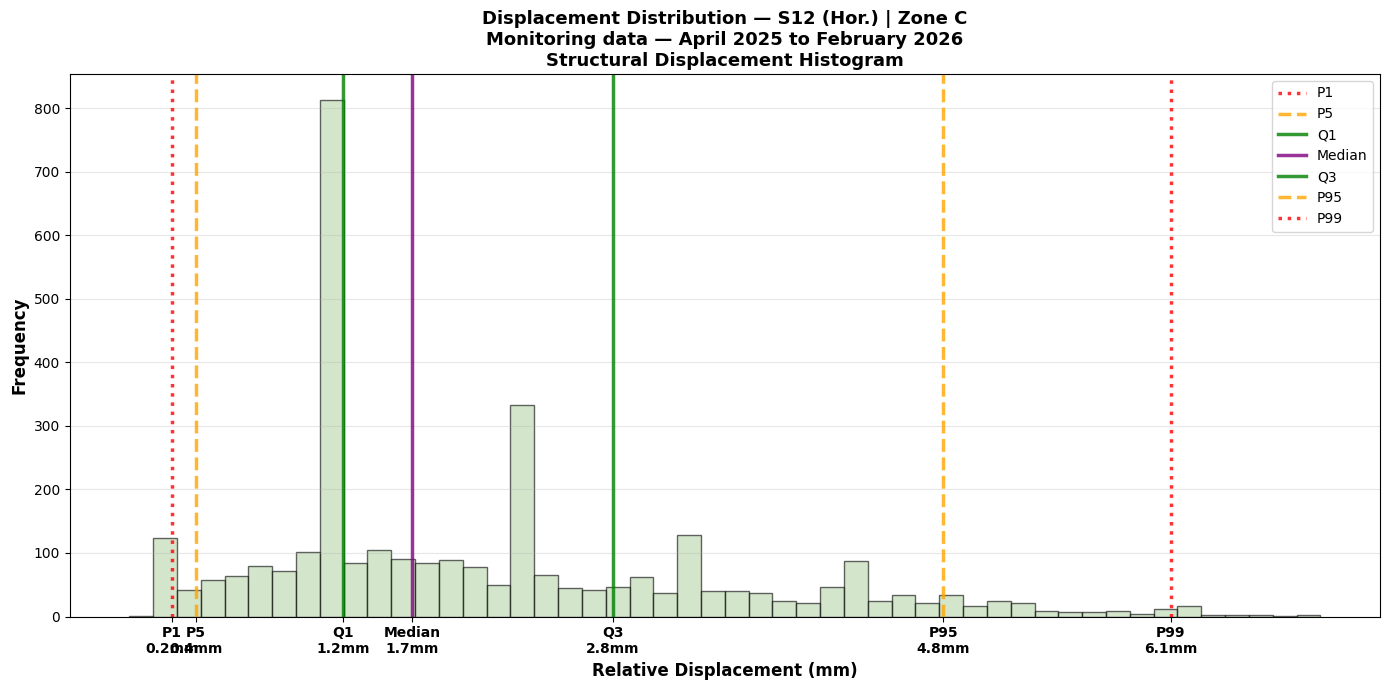

In [63]:
# ============================================================
# 7.1. RELATIVE DISPLACEMENT HISTOGRAM
# ============================================================
fig, ax = plt.subplots(figsize=(14, 7))

ax.hist(datos_movimiento, bins=50, edgecolor='black', alpha=0.6, color=config['color'])

lineas_refs = [
    (p1,  'P1',     'red',    ':'),
    (p5,  'P5',     'orange', '--'),
    (Q1,  'Q1',     'green',  '-'),
    (p50, 'Median', 'purple', '-'),
    (Q3,  'Q3',     'green',  '-'),
    (p95, 'P95',    'orange', '--'),
    (p99, 'P99',    'red',    ':')
]

for valor, etiqueta, color, estilo in lineas_refs:
    ax.axvline(valor, color=color, linestyle=estilo, linewidth=2.5, alpha=0.8, label=etiqueta)

margen = (datos_movimiento.max() - datos_movimiento.min()) * 0.05
ax.set_xlim(datos_movimiento.min() - margen, datos_movimiento.max() + margen)

valores_x_custom  = [p1, p5, Q1, p50, Q3, p95, p99]
etiquetas_x_custom = [f'P1\n{p1:.1f}mm', f'P5\n{p5:.1f}mm', f'Q1\n{Q1:.1f}mm',
                      f'Median\n{p50:.1f}mm', f'Q3\n{Q3:.1f}mm',
                      f'P95\n{p95:.1f}mm', f'P99\n{p99:.1f}mm']

ax.set_xticks(valores_x_custom)
ax.set_xticklabels(etiquetas_x_custom, fontsize=10, fontweight='bold')
ax.set_xlabel('Relative Displacement (mm)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title(f'Displacement Distribution — {sensor} {config["axis"]} | {config["zone"]}\n'
             f'Monitoring data — April 2025 to February 2026\n'
             f'Structural Displacement Histogram',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

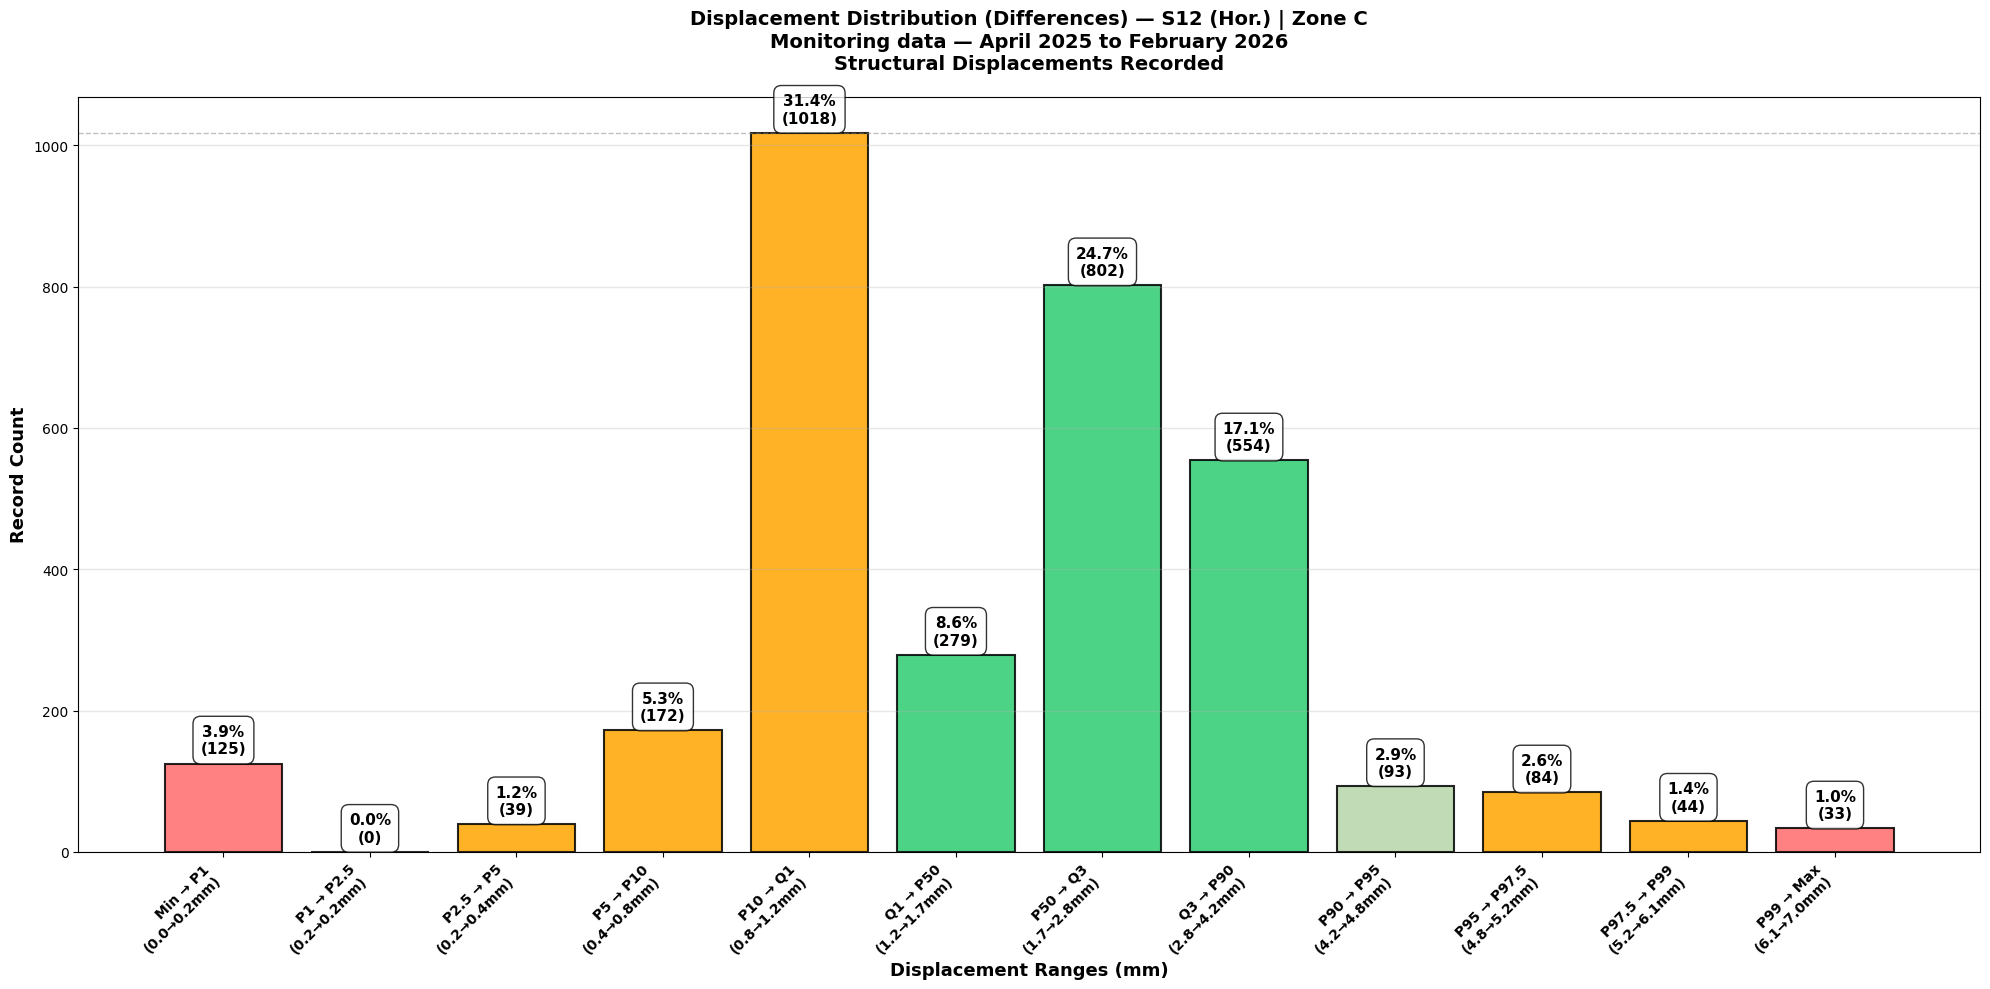

In [64]:
# ============================================================
# 7.2. DISPLACEMENT RANGE BAR CHART
# Shows count and percentage of records in each percentile band
# ============================================================
rangos_data_dif = []
rango_1 = len(datos_movimiento[datos_movimiento <= p1])
rangos_data_dif.append({'Range': 'Min → P1', 'Lower (mm)': f'{0:.1f}', 'Upper (mm)': f'{p1:.1f}',
                        'Count': rango_1, '%': f'{(rango_1/len(datos_movimiento)*100):.2f}%',
                        'Cumulative': f'{(rango_1/len(datos_movimiento)*100):.2f}%'})

rangos_intermedios = [
    ('P1', p1, 'P2.5', p2_5), ('P2.5', p2_5, 'P5', p5), ('P5', p5, 'P10', p10),
    ('P10', p10, 'Q1', Q1), ('Q1', Q1, 'P50', p50), ('P50', p50, 'Q3', Q3),
    ('Q3', Q3, 'P90', p90), ('P90', p90, 'P95', p95), ('P95', p95, 'P97.5', p97_5),
    ('P97.5', p97_5, 'P99', p99),
]

acumulado_anterior = rango_1
for nombre_inf, val_inf, nombre_sup, val_sup in rangos_intermedios:
    n = len(datos_movimiento[(datos_movimiento > val_inf) & (datos_movimiento <= val_sup)])
    acumulado = acumulado_anterior + n
    rangos_data_dif.append({'Range': f'{nombre_inf} → {nombre_sup}', 'Lower (mm)': f'{val_inf:.1f}',
                            'Upper (mm)': f'{val_sup:.1f}', 'Count': n,
                            '%': f'{(n/len(datos_movimiento)*100):.2f}%',
                            'Cumulative': f'{(acumulado/len(datos_movimiento)*100):.2f}%'})
    acumulado_anterior = acumulado

rango_final = len(datos_movimiento[datos_movimiento > p99])
rangos_data_dif.append({'Range': 'P99 → Max', 'Lower (mm)': f'{p99:.1f}', 'Upper (mm)': f'{movimiento_total:.1f}',
                        'Count': rango_final, '%': f'{(rango_final/len(datos_movimiento)*100):.2f}%',
                        'Cumulative': '100.00%'})

df_rangos_dif = pd.DataFrame(rangos_data_dif)

# Bar chart
fig, ax = plt.subplots(figsize=(20, 10))

rangos_nombres    = df_rangos_dif['Range'].tolist()
rangos_cantidades = df_rangos_dif['Count'].tolist()
rangos_porcentajes = [float(x.rstrip('%')) for x in df_rangos_dif['%'].tolist()]
rangos_limites_inf = [float(x) for x in df_rangos_dif['Lower (mm)'].tolist()]
rangos_limites_sup = [float(x) for x in df_rangos_dif['Upper (mm)'].tolist()]

rangos_etiquetas = [f"{r}\n({rangos_limites_inf[i]:.1f}→{rangos_limites_sup[i]:.1f}mm)"
                    for i, r in enumerate(rangos_nombres)]

colores = []
for i, r in enumerate(rangos_nombres):
    if i == 0 or i == len(rangos_nombres) - 1:
        colores.append('#ff6b6b')
    elif 'P1' in r or 'P99' in r or 'P97.5' in r or 'P2.5' in r:
        colores.append('#ffa500')
    elif 'Q1' in r or 'P50' in r or 'Q3' in r:
        colores.append('#2ecc71')
    else:
        colores.append(config['color'])

barras = ax.bar(range(len(rangos_nombres)), rangos_cantidades, color=colores,
                edgecolor='black', linewidth=1.5, alpha=0.85, width=0.8)

for i, (barra, pct, cant) in enumerate(zip(barras, rangos_porcentajes, rangos_cantidades)):
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2., altura + max(rangos_cantidades)*0.01,
            f'{pct:.1f}%\n({int(cant)})', ha='center', va='bottom', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='black'))

ax.set_xlabel('Displacement Ranges (mm)', fontsize=13, fontweight='bold')
ax.set_ylabel('Record Count', fontsize=13, fontweight='bold')
ax.set_title(f'Displacement Distribution (Differences) — {sensor} {config["axis"]} | {config["zone"]}\n'
             f'Monitoring data — April 2025 to February 2026\n'
             f'Structural Displacements Recorded',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(range(len(rangos_nombres)))
ax.set_xticklabels(rangos_etiquetas, rotation=45, ha='right', fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y', linewidth=1)
ax.axhline(max(rangos_cantidades), color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.subplots_adjust(top=0.95, bottom=0.15, left=0.08, right=0.98)
plt.tight_layout()
plt.show()

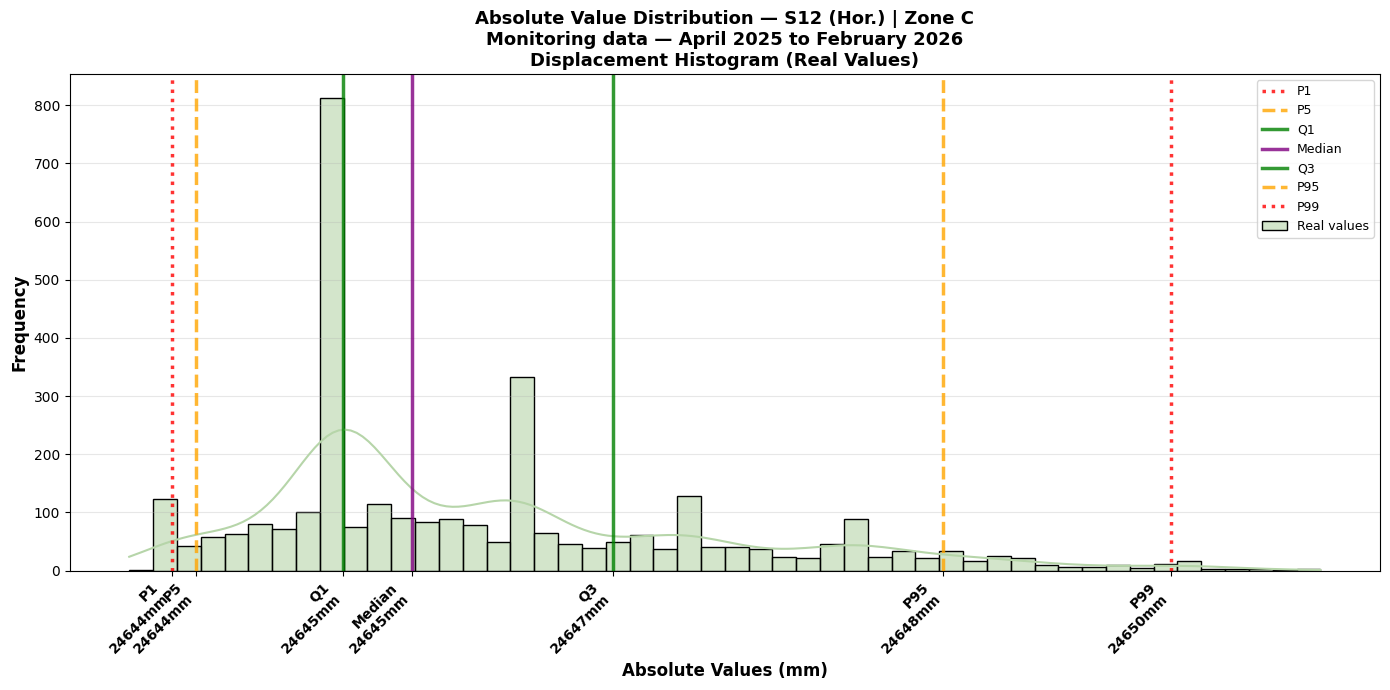

In [65]:
# ============================================================
# 7.3. ABSOLUTE VALUES HISTOGRAM
# Shows actual sensor readings (raw distance measurements)
# ============================================================
fig, ax = plt.subplots(figsize=(14, 7))

sns.histplot(datos, bins=50, edgecolor='black', kde=True, alpha=0.6,
             color=config['color'], label='Real values', ax=ax)

lineas_refs_reales = [
    (datos_min + p1,  'P1',     'red',    ':'),
    (datos_min + p5,  'P5',     'orange', '--'),
    (datos_min + Q1,  'Q1',     'green',  '-'),
    (datos_min + p50, 'Median', 'purple', '-'),
    (datos_min + Q3,  'Q3',     'green',  '-'),
    (datos_min + p95, 'P95',    'orange', '--'),
    (datos_min + p99, 'P99',    'red',    ':')
]

for valor, etiqueta, color, estilo in lineas_refs_reales:
    ax.axvline(valor, color=color, linestyle=estilo, linewidth=2.5, alpha=0.8, label=etiqueta)

margen = (datos.max() - datos.min()) * 0.05
ax.set_xlim(datos.min() - margen, datos.max() + margen)

valores_x_custom   = [datos_min + p1, datos_min + p5, datos_min + Q1, datos_min + p50,
                      datos_min + Q3, datos_min + p95, datos_min + p99]
etiquetas_x_custom = [f'P1\n{datos_min+p1:.0f}mm', f'P5\n{datos_min+p5:.0f}mm',
                      f'Q1\n{datos_min+Q1:.0f}mm', f'Median\n{datos_min+p50:.0f}mm',
                      f'Q3\n{datos_min+Q3:.0f}mm', f'P95\n{datos_min+p95:.0f}mm',
                      f'P99\n{datos_min+p99:.0f}mm']

ax.set_xticks(valores_x_custom)
ax.set_xticklabels(etiquetas_x_custom, fontsize=10, fontweight='bold', rotation=45, ha='right')
ax.set_xlabel('Absolute Values (mm)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title(f'Absolute Value Distribution — {sensor} {config["axis"]} | {config["zone"]}\n'
             f'Monitoring data — April 2025 to February 2026\n'
             f'Displacement Histogram (Real Values)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

---
## 8. Clean Data — Environmental Correlation

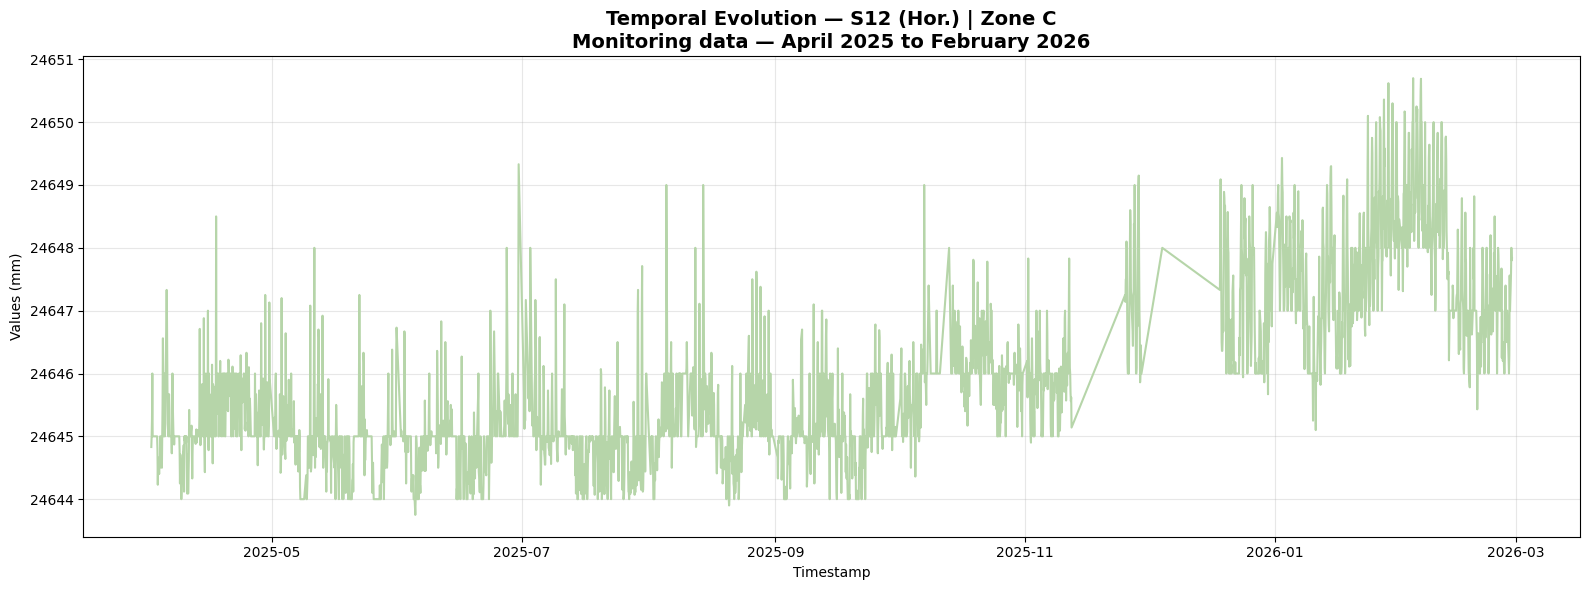

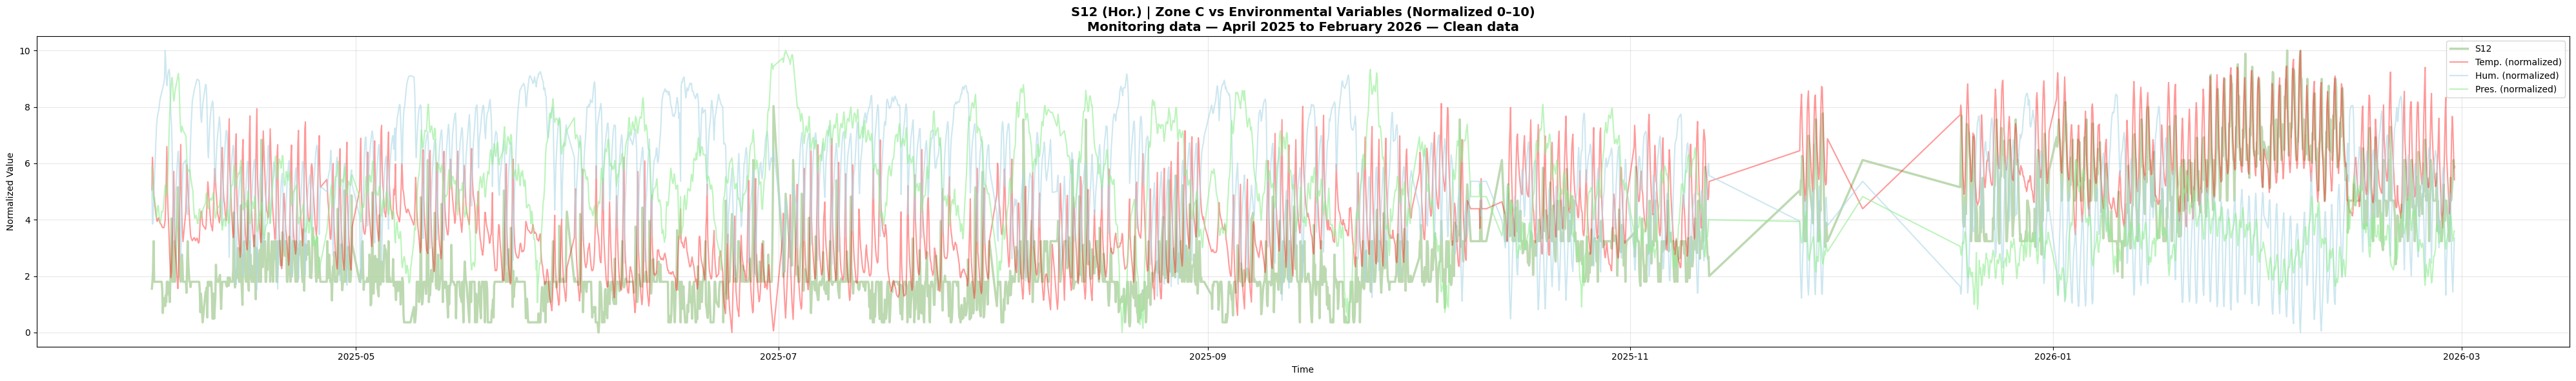

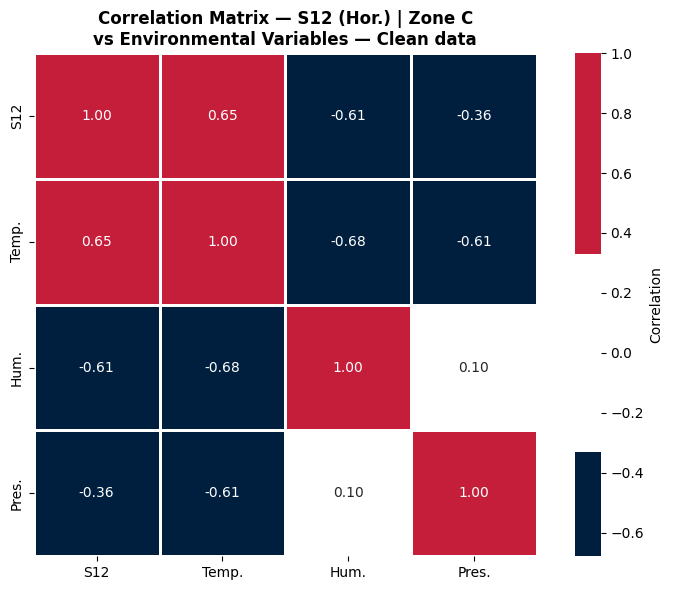

In [66]:
# ============================================================
# 8. CLEAN DATA — FULL ENVIRONMENTAL CONTEXT
# Exploratory section — runs on active sensor from Section 0.
# Not part of the automated pipeline. Produces no output files.
# ============================================================

# Rebuild single-sensor DataFrame from raw data
df_raw_s8 = pd.read_csv(RAW_DATA_PATH)
df_raw_s8['Timestamp'] = pd.to_datetime(df_raw_s8['Timestamp'], format='%Y-%m-%d %H:%M:%S')
df_raw_s8 = df_raw_s8[df_raw_s8['Timestamp'].dt.month.isin([1,2,4,5,6,7,8,9,10,11,12])].copy()
df_limpio = df_raw_s8[['Timestamp', sensor, 'Hum.', 'Pres.', 'Temp.']].dropna(subset=[sensor]).copy()
config = SENSOR_CONFIG[sensor]

# Apply physical validity filters if defined for this sensor
geo_threshold = GEOMETRIC_THRESHOLDS.get(sensor)
if geo_threshold is not None:
    df_limpio = df_limpio[df_limpio[sensor] >= geo_threshold].copy()

max_roc = MAX_RATE_OF_CHANGE.get(sensor)
if max_roc is not None:
    df_limpio = df_limpio.sort_values('Timestamp').reset_index(drop=True)
    mask = (df_limpio[sensor].diff().abs() <= max_roc) | (df_limpio[sensor].diff().isna())
    df_limpio = df_limpio[mask].copy().reset_index(drop=True)

# Apply Chauvenet + IQR to get post-IQR values
datos_s8, _, _ = criterio_chauvenet(df_limpio[sensor], verbose=False)
optimal_k_s8 = K_FACTORS[sensor]
datos_post_iqr_s8, _, _, _, _, _, _ = criterio_iqr(datos_s8, k=optimal_k_s8, verbose=False)

# Rebuild clean DataFrame
df_limpio_final = df_limpio.loc[df_limpio[sensor].isin(datos_post_iqr_s8)].copy()

# 8.1. Temporal evolution
plt.figure(figsize=(16, 6))
sns.lineplot(data=df_limpio_final, x='Timestamp', y=sensor, linewidth=1.5, color=config['color'])
plt.title(f'Temporal Evolution — {sensor} {config["axis"]} | {config["zone"]}\n'
          f'Monitoring data — April 2025 to February 2026',
          fontsize=14, fontweight='bold')
plt.xlabel('Timestamp')
plt.ylabel('Values (mm)')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8.2. Normalize for overlay
df_normalized_clean = df_limpio_final.copy()
scaler_s = MinMaxScaler(feature_range=(0, 10))
df_normalized_clean[sensor] = scaler_s.fit_transform(df_limpio_final[[sensor]])
for var in ['Temp.', 'Hum.', 'Pres.']:
    scaler_v = MinMaxScaler(feature_range=(0, 10))
    df_normalized_clean[var] = scaler_v.fit_transform(df_limpio_final[[var]].fillna(df_limpio_final[var].mean()))

# 8.3. Sensor vs environmental overlay
plt.figure(figsize=(40, 6))
plt.plot(df_normalized_clean['Timestamp'], df_normalized_clean[sensor],
         label=sensor, linewidth=2.5, color=config['color'], alpha=0.9)
plt.plot(df_normalized_clean['Timestamp'], df_normalized_clean['Temp.'],
         label='Temp. (normalized)', linewidth=1.5, alpha=0.4, color='red')
plt.plot(df_normalized_clean['Timestamp'], df_normalized_clean['Hum.'],
         label='Hum. (normalized)', linewidth=1.5, alpha=0.6, color='lightblue')
plt.plot(df_normalized_clean['Timestamp'], df_normalized_clean['Pres.'],
         label='Pres. (normalized)', linewidth=1.5, alpha=0.6, color='lightgreen')
plt.title(f'{sensor} {config["axis"]} | {config["zone"]} vs Environmental Variables (Normalized 0–10)\n'
          f'Monitoring data — April 2025 to February 2026 — Clean data',
          fontsize=14, fontweight='bold')
plt.xlabel('Time')
plt.ylabel('Normalized Value')
plt.legend(loc='upper right', fontsize=10)
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8.4. Correlation matrix — clean data
correlation_clean = df_limpio_final[[sensor, 'Temp.', 'Hum.', 'Pres.']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_clean, annot=True, fmt='.2f',
            cmap=['#001F3F', '#FFFFFF', '#C41E3A'],
            center=0, square=True, linewidths=2, cbar_kws={'label': 'Correlation'})
plt.title(f'Correlation Matrix — {sensor} {config["axis"]} | {config["zone"]}\n'
          f'vs Environmental Variables — Clean data',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Temporal Evolution with IQR Percentile Bands

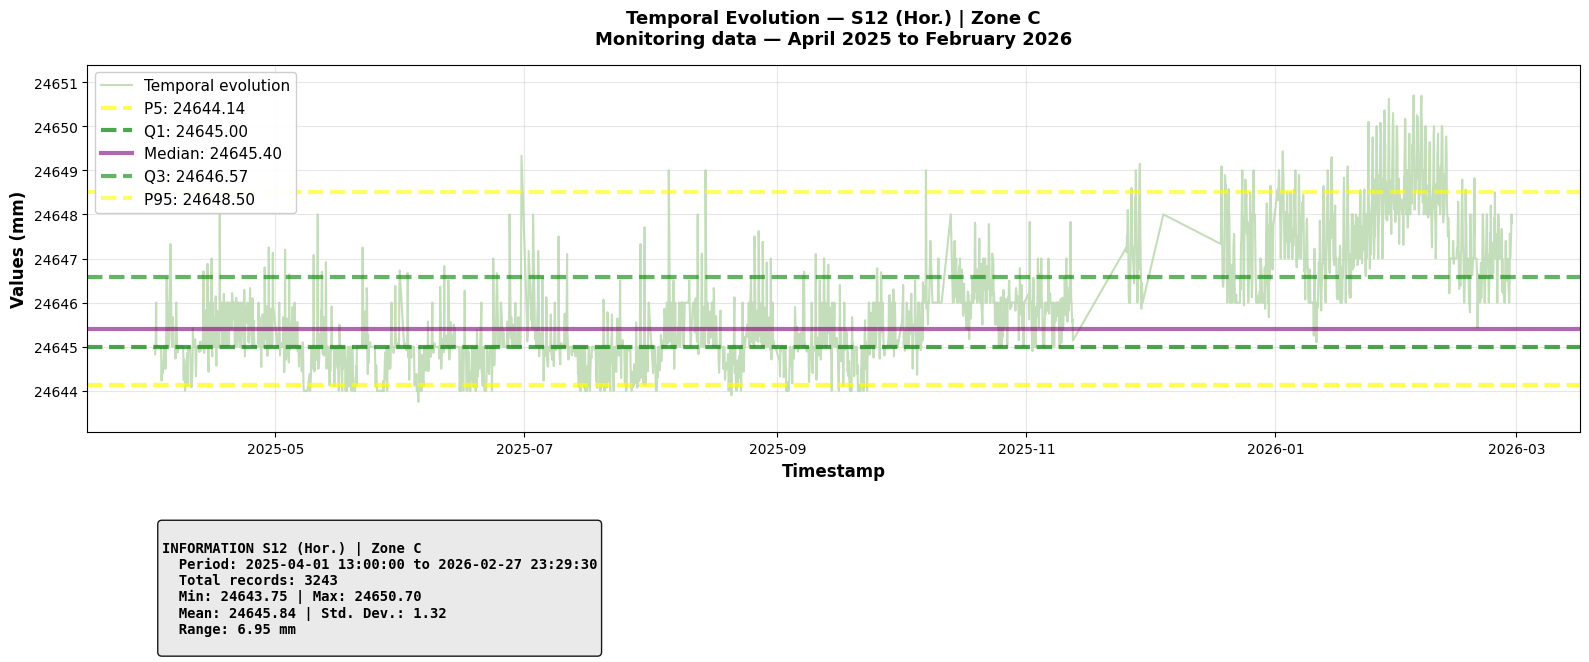

In [67]:
# ============================================================
# 10. TEMPORAL EVOLUTION WITH PERCENTILE BANDS
# Shows structural behavior against IQR reference lines
# ============================================================
datos_plot = df_limpio_final[sensor].dropna()

valor_min = datos_plot.min()
valor_max = datos_plot.max()
rango     = valor_max - valor_min
colchon   = rango * 0.1

y_min = valor_min - colchon
y_max = valor_max + colchon

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(df_limpio_final['Timestamp'], df_limpio_final[sensor],
        linewidth=1.5, alpha=0.8, color=config['color'], label='Temporal evolution')

ax.set_ylim(y_min, y_max)

ax.axhline(datos_min + p5,  color='yellow', linestyle='--', linewidth=3, alpha=0.7, label=f'P5: {datos_min+p5:.2f}')
ax.axhline(datos_min + Q1,  color='green',  linestyle='--', linewidth=3, alpha=0.7, label=f'Q1: {datos_min+Q1:.2f}')
ax.axhline(datos_min + p50, color='purple', linestyle='-',  linewidth=3, alpha=0.6, label=f'Median: {datos_min+p50:.2f}')
ax.axhline(datos_min + Q3,  color='green',  linestyle='--', linewidth=3, alpha=0.6, label=f'Q3: {datos_min+Q3:.2f}')
ax.axhline(datos_min + p95, color='yellow', linestyle='--', linewidth=3, alpha=0.6, label=f'P95: {datos_min+p95:.2f}')

ax.set_title(f'Temporal Evolution — {sensor} {config["axis"]} | {config["zone"]}\n'
             f'Monitoring data — April 2025 to February 2026',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Timestamp', fontsize=12, fontweight='bold')
ax.set_ylabel('Values (mm)', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=0)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)

info_text = f"""
INFORMATION {sensor} {config['axis']} | {config['zone']}
  Period: {df_limpio_final['Timestamp'].min()} to {df_limpio_final['Timestamp'].max()}
  Total records: {len(df_limpio_final)}
  Min: {valor_min:.2f} | Max: {valor_max:.2f}
  Mean: {datos_plot.mean():.2f} | Std. Dev.: {datos_plot.std():.2f}
  Range: {rango:.2f} mm
"""

ax.text(0.05, -0.25, info_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round', facecolor='#E8E8E8', alpha=0.9),
        family='monospace', fontweight='bold')

plt.subplots_adjust(bottom=0.20)
plt.tight_layout()
plt.show()

---
## 10. Export Clean CSV

In [68]:
# ============================================================
# 11. EXPORT CLEAN CSV
# One file per sensor — consumed by 03_statistical_analysis.ipynb
# ============================================================
output_path = os.path.join(PROCESSED_DATA_PATH, f'clean_{sensor}.csv')
df_limpio_final.to_csv(output_path, index=False)

print(f"Clean data exported: {output_path}")
print(f"Records: {len(df_limpio_final)}")
print(f"Columns: {df_limpio_final.columns.tolist()}")
print(f"\nTo run for the next sensor, change 'sensor' in Section 0 and re-run all cells.")

Clean data exported: ../data/processed/clean_S12.csv
Records: 3243
Columns: ['Timestamp', 'S12', 'Hum.', 'Pres.', 'Temp.']

To run for the next sensor, change 'sensor' in Section 0 and re-run all cells.


---
## Summary

This notebook applied a three-phase cleaning pipeline to the active sensor:

| Phase | Method | Purpose |
|-------|--------|---------|
| 1 | Geometric filter | Remove physically impossible values |
| 2 | Chauvenet Criterion | Remove statistical population outliers |
| 3 | IQR (k-factor) | Define valid structural operating envelope |

**Next:** `03_statistical_analysis.ipynb` — load all 12 clean CSVs and compute comparative statistics.